# Detractor EDA — Univariate & Multivariate Composition Analysis

Dataset: `detractor_last4.csv` — all 5,356 detractor orders from the last 4 weeks.

**Sections**
1. Importing Libraries  
2. Load Data  
3. Feature Engineering  
4. Univariate Composition Analysis  
5. Multivariate Composition Analysis (Feature Intersections)

## 1. Importing Libraries

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import ast
import re
from itertools import combinations

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.2f}".format)

# ── colour palette ──────────────────────────────────────────────────────────
PALETTE  = sns.color_palette("Set2", 10)
BAR_CLR  = "#4C72B0"
PCT_CLR  = "#DD8452"

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Load Data

In [105]:
responses_data = pd.read_csv("responses_last4.csv", low_memory=False)
responses_data["is_detractor"] = (responses_data["CLASSIFICATION"] == "Detractor").astype(int)
df = responses_data  # alias — feature engineering runs on the full dataset

overall_rate = responses_data["is_detractor"].mean() * 100
print(f"Rows: {len(responses_data):,}  |  Columns: {responses_data.shape[1]}")
print(f"\nCLASSIFICATION breakdown:")
print(responses_data["CLASSIFICATION"].value_counts().rename("count").to_frame().assign(pct=lambda x: (x["count"]/len(responses_data)*100).round(1)))
print(f"\n>>> Overall Detractor Rate: {overall_rate:.2f}%  (baseline for all charts)")


Rows: 55,029  |  Columns: 58

CLASSIFICATION breakdown:
                count   pct
CLASSIFICATION             
Promoter        45462 82.60
Detractor        5409  9.80
Neutral          4158  7.60

>>> Overall Detractor Rate: 9.83%  (baseline for all charts)


## 3. Feature Engineering

Build every feature needed for the composition analysis.

### 3.1 Date Parsing & Time-Based Features

In [106]:
# ── parse datetime columns ─────────────────────────────────────────────────
dt_cols = [
    "ORDER_CREATED_TS_IST", "SHIFTING_TS_IST",
    "VENDOR_OWNER_ACCEPTED_TS_IST", "ORDER_COMPLETED_TS_IST",
]
for c in dt_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce")

# ── creation → shifting date diff (days) ──────────────────────────────────
df["creation_to_shifting_days"] = (
    df["SHIFTING_TS_IST"] - df["ORDER_CREATED_TS_IST"]
).dt.total_seconds() / 86400

# ── weekend / weekday flag ─────────────────────────────────────────────────
df["weekend_flag"] = df["SHIFTING_TS_IST"].dt.dayofweek.map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

print("Date features built ✓")
print(df[["creation_to_shifting_days", "weekend_flag"]].describe(include="all"))

Date features built ✓
        creation_to_shifting_days weekend_flag
count                    55029.00        55029
unique                        NaN            2
top                           NaN      Weekday
freq                          NaN        32852
mean                         2.37          NaN
std                          4.32          NaN
min                         -0.52          NaN
25%                          0.40          NaN
50%                          0.95          NaN
75%                          2.66          NaN
max                        326.90          NaN


### 3.2 Item-Level Flags (from ITEMS_LIST)

In [107]:
items = df["ITEMS_LIST"].fillna("").str.lower()

df["has_fridge"]          = items.str.contains(r"fridge",            regex=True).astype(int)
df["has_washing_machine"] = items.str.contains(r"washing machine",   regex=True).astype(int)
df["has_ac"]              = items.str.contains(r"\bac\b|air.cond|cooler", regex=True).astype(int)
df["has_almirah"]         = items.str.contains(r"almirah|wardrobe",  regex=True).astype(int)

item_flags = ["has_fridge", "has_washing_machine", "has_ac", "has_almirah"]
print("Item flags — share of detractor orders:")
print((df[item_flags].mean() * 100).round(1).rename("% orders"))

Item flags — share of detractor orders:
has_fridge            59.70
has_washing_machine   54.60
has_ac                37.50
has_almirah           37.60
Name: % orders, dtype: float64


### 3.3 Add-On Service Flags (from ADD_ONS)

In [108]:
addons = df["ADD_ONS"].fillna("").str.lower()

df["has_installation"]   = addons.str.contains(r"installation",  regex=True).astype(int)
df["has_uninstallation"] = addons.str.contains(r"uninstallation",regex=True).astype(int)
df["has_packing"]        = addons.str.contains(r"packing",       regex=True).astype(int)
df["has_unpacking"]      = addons.str.contains(r"unpacking",     regex=True).astype(int)

addon_flags = ["has_installation", "has_uninstallation", "has_packing", "has_unpacking"]
print("Add-on flags — share of detractor orders:")
print((df[addon_flags].mean() * 100).round(1).rename("% orders"))

Add-on flags — share of detractor orders:
has_installation     22.20
has_uninstallation   21.20
has_packing          78.10
has_unpacking        21.40
Name: % orders, dtype: float64


### 3.4 Ticket & Operational Features

In [109]:
# ── vendor tickets = supervisor + owner tickets ────────────────────────────
df["vendor_tickets"] = df["VENDOR_SUPERVISOR_TICKETS"] + df["VENDOR_OWNER_TICKETS"]

# ── CFT change ────────────────────────────────────────────────────────────
df["cft_change"] = df["FINAL_CFT"] - df["INITIAL_CFT"]
df["cft_change_pct"] = (df["cft_change"] / df["INITIAL_CFT"]) * 100

# ── OTA flag (binary) ─────────────────────────────────────────────────────
# OTA_FLAG = 'On_Time' → on time; NaN → OTA breached
df["ota_binary"] = df["OTA_FLAG"].fillna("OTA_Breach").map(
    lambda x: "On Time" if x == "On_Time" else "OTA Breach"
)

# ── 0-km order flag (dry-run distance < 1 km) ────────────────────────────
df["zero_km_flag"] = (df["DRY_RUN_DISTANCE_KMS"].fillna(0) < 1).map(
    {True: "0-km Order", False: "Non 0-km"}
)

# ── customer AND vendor both raised tickets flag ──────────────────────────
df["cust_vendor_both_ticket"] = (
    (df["CUSTOMER_TICKETS"] > 0) & (df["vendor_tickets"] > 0)
).map({True: "Both Raised", False: "Not Both"})

# ── floor (use pickup floor as primary floor) ─────────────────────────────
df["floor"] = df["PICKUP_FLOOR"]

print("Ticket & operational features built ✓")
print(df[["vendor_tickets","cft_change","ota_binary","zero_km_flag","cust_vendor_both_ticket"]].head(3))

Ticket & operational features built ✓
   vendor_tickets  cft_change ota_binary zero_km_flag cust_vendor_both_ticket
0               0           0    On Time     Non 0-km                Not Both
1               0         -57    On Time     Non 0-km                Not Both
2               0           0    On Time     Non 0-km                Not Both


### 3.5 Supervisor Behavioural Ticket Count

For each order we count how many **behaviour / hygiene** tickets the order's supervisor has raised *across all their orders* in the dataset.  
Ticket text searched: `"Crew Behaviour / Hygiene"` inside `ISSUE_SUBISSUE_DICTIONARY`.

In [110]:
def count_behavioural_tickets(issue_dict_str: str) -> int:
    """Count occurrences of 'Crew Behaviour / Hygiene' in one order's issue dict."""
    if pd.isna(issue_dict_str) or issue_dict_str in ("{}", ""):
        return 0
    return issue_dict_str.lower().count("crew behaviour")

df["order_behavioural_tickets"] = df["ISSUE_SUBISSUE_DICTIONARY"].apply(count_behavioural_tickets)

# Aggregate: total behavioural tickets per supervisor (across all their orders)
sup_bhv = (
    df.groupby("SUPERVISOR_ID")["order_behavioural_tickets"]
    .sum()
    .rename("supervisor_behavioural_tickets")
)
df = df.merge(sup_bhv, on="SUPERVISOR_ID", how="left")
responses_data = df  # re-sync alias after merge creates a new dataframe object

print("Supervisor behavioural ticket distribution:")
print(df["supervisor_behavioural_tickets"].describe().round(2))


Supervisor behavioural ticket distribution:
count   55029.00
mean        0.63
std         1.08
min         0.00
25%         0.00
50%         0.00
75%         1.00
max         9.00
Name: supervisor_behavioural_tickets, dtype: float64


### 3.6 Bucketing Continuous Features for Composition Plots

In [114]:
# ── Bins for multivariate cross-tabs (Section 5) ─────────────────────────────

# ticket groupings
df["total_tickets_bin"]     = pd.cut(df["TOTAL_TICKETS"],         bins=[-1,0,1,2,3,999],   labels=["0","1","2","3","4+"])
df["customer_tickets_bin"]  = pd.cut(df["CUSTOMER_TICKETS"],      bins=[-1,0,1,2,999],     labels=["0","1","2","3+"])
df["vendor_tickets_bin"]    = pd.cut(df["vendor_tickets"],        bins=[-1,0,1,2,999],     labels=["0","1","2","3+"])
df["sprinklr_sessions_bin"] = pd.cut(df["SPRINKLR_SESSION_COUNT"],bins=[-1,0,1,2,3,999],   labels=["0","1","2","3","4+"])
df["sup_bhv_bin"]           = pd.cut(df["supervisor_behavioural_tickets"], bins=[-1,0,1,2,9999], labels=["0","1","2","3+"])

# floor grouping
df["floor_bin"] = pd.cut(df["PICKUP_FLOOR"], bins=[-1,0,2,4,6,99], labels=["0","1-2","3-4","5-6","7+"])

# dry-run grouping
df["dry_run_bin"] = pd.cut(
    df["DRY_RUN_DISTANCE_KMS"].fillna(-1),
    bins=[-2, 0, 5, 10, 20, 9999],
    labels=["0 km", "1-5 km", "5-10 km", "10-20 km", "20+ km"]
)

# CFT change grouping
df["cft_change_pct_bin"] = pd.cut(
    df["cft_change_pct"],
    bins=[-999, -20, -10, -5, 0, 5, 10, 20, 50, 999],
    labels=[
        "<-20%", "-20% to -10%", "-10% to -5%", "-5% to 0%",
        "0–5%", "5–10%", "10–20%", "20–50%", ">50%"
    ]
)

df["cft_change_pct_bin"] = df["cft_change_pct_bin"].cat.add_categories(["Missing"]).fillna("Missing")

# booking lead grouping
df["booking_lead_bin"] = pd.cut(
    df["creation_to_shifting_days"],
    bins=[-1,0,1,3,7,9999],
    labels=["Same Day","1 day","2-3 days","4-7 days","7+ days"]
)

# resolution TAT grouping (minutes → hour buckets)
df["resolution_tat_bin"] = pd.cut(
    df["AVG_RESOLUTION_TAT"].fillna(0),
    bins=[-1, 60, 180, 360, 720, 1440, 2880, 3600, 999999],
    labels=[
        "0–1 hr",
        "1–3 hr",
        "3–6 hr",
        "6–12 hr",
        "12–24 hr",
        "24–48 hr",
        "48–60 hr",
        "60+ hr"
    ]
)

# Final fare grouping
df["final_fare_bin"] = pd.cut(
    df["FINAL_FARE"],
    bins=[0, 2000, 4000, 6000, 8000, 10000, 999999],
    labels=["<2k", "2-4k", "4-6k", "6-8k", "8-10k", "10k+"]
)

# Final CFT grouping
df["final_cft_bin"] = pd.cut(
    df["FINAL_CFT"],
    bins=[0, 200, 400, 600, 800, 999999],
    labels=["<200", "200-400", "400-600", "600-800", "800+"]
)

print("Bins created ✓")
print("Discrete counts will use raw values in Section 4.1; continuous features use histograms in Section 4.2.")


Bins created ✓
Discrete counts will use raw values in Section 4.1; continuous features use histograms in Section 4.2.


## 4. Univariate Detractor Rate Analysis

**Metric:** Detractor Rate (%) = detractors in segment / total responses in segment.  
Red dashed line = overall detractor rate baseline (**10.81 %**).

- **Categorical & integer count features** → bar chart with actual values on x-axis  
- **Continuous features** → KDE density plot comparing Detractors vs Non-Detractors

In [112]:
def univariate_bar(series, title, ax=None, color=BAR_CLR, rotate=0):
    """
    Bar chart showing detractor rate (%) for each segment.
    Bars = detractor rate per bucket; dashed line = overall baseline.
    Annotations show rate % and total count (n) per segment.
    """
    det_mask     = responses_data["is_detractor"] == 1
    total_counts = series.value_counts(dropna=False).sort_index()
    det_counts   = series[det_mask].value_counts(dropna=False).sort_index()
    det_rate     = (det_counts / total_counts * 100).fillna(0).round(1).reindex(total_counts.index, fill_value=0)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(max(6, len(total_counts) * 0.9), 4.5))

    bars = ax.bar(total_counts.index.astype(str), det_rate.values, color=color, alpha=0.85, zorder=2)

    # Overall baseline
    ax.axhline(overall_rate, color=PCT_CLR, linestyle="--", linewidth=1.5, zorder=3, alpha=0.85)
    ax.text(len(total_counts) - 0.5, overall_rate + 0.5,
            f"Overall: {overall_rate:.1f}%", ha="right", va="bottom", fontsize=7.5, color=PCT_CLR)

    # Annotate bars: rate % + count
    y_max = det_rate.values.max() if det_rate.values.max() > 0 else 1
    for bar, rate, cnt in zip(bars, det_rate.values, total_counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + y_max * 0.02,
            f"{rate:.1f}%\n(n={cnt:,})", ha="center", va="bottom", fontsize=8, fontweight="bold"
        )

    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("Detractor Rate (%)", fontsize=9)
    ax.tick_params(axis="x", rotation=rotate)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(0, max(y_max * 1.45, overall_rate * 1.6))

    if standalone:
        plt.tight_layout()
        plt.show()


def univariate_hist(col, title, ax=None, bins=25, clip=None, rotate=0):
    """
    Histogram-style detractor rate chart for continuous features.
    Uses auto-binning on absolute values; bars show detractor rate per bin.
    Bins with fewer than 5 responses are skipped.
    """
    data     = responses_data[col].dropna()
    det_data = responses_data.loc[responses_data["is_detractor"] == 1, col].dropna()

    if clip is not None:
        data     = data.clip(upper=clip)
        det_data = det_data.clip(upper=clip)

    counts,     bin_edges = np.histogram(data, bins=bins)
    det_counts, _         = np.histogram(det_data, bins=bin_edges)

    det_rate    = np.where(counts >= 5, det_counts / counts * 100, np.nan)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = (bin_edges[1] - bin_edges[0]) * 0.85

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 4.5))

    valid = ~np.isnan(det_rate)
    ax.bar(bin_centers[valid], det_rate[valid], width=bin_width,
           color=BAR_CLR, alpha=0.85, zorder=2)

    # Overall baseline
    ax.axhline(overall_rate, color=PCT_CLR, linestyle="--", linewidth=1.5, zorder=3, alpha=0.85)
    ax.text(bin_centers[-1], overall_rate + 0.5,
            f"Overall: {overall_rate:.1f}%", ha="right", va="bottom", fontsize=7.5, color=PCT_CLR)

    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel(col if clip is None else f"{col}  (clipped at {clip})", fontsize=9)
    ax.set_ylabel("Detractor Rate (%)", fontsize=9)
    ax.tick_params(axis="x", rotation=rotate)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

    y_max = np.nanmax(det_rate) if np.any(valid) else overall_rate
    ax.set_ylim(0, max(y_max * 1.35, overall_rate * 1.6))

    if standalone:
        plt.tight_layout()
        plt.show()


print("Helper functions `univariate_bar` and `univariate_hist` ready ✓")


Helper functions `univariate_bar` and `univariate_hist` ready ✓


### 4.1 Ticket-Based Features

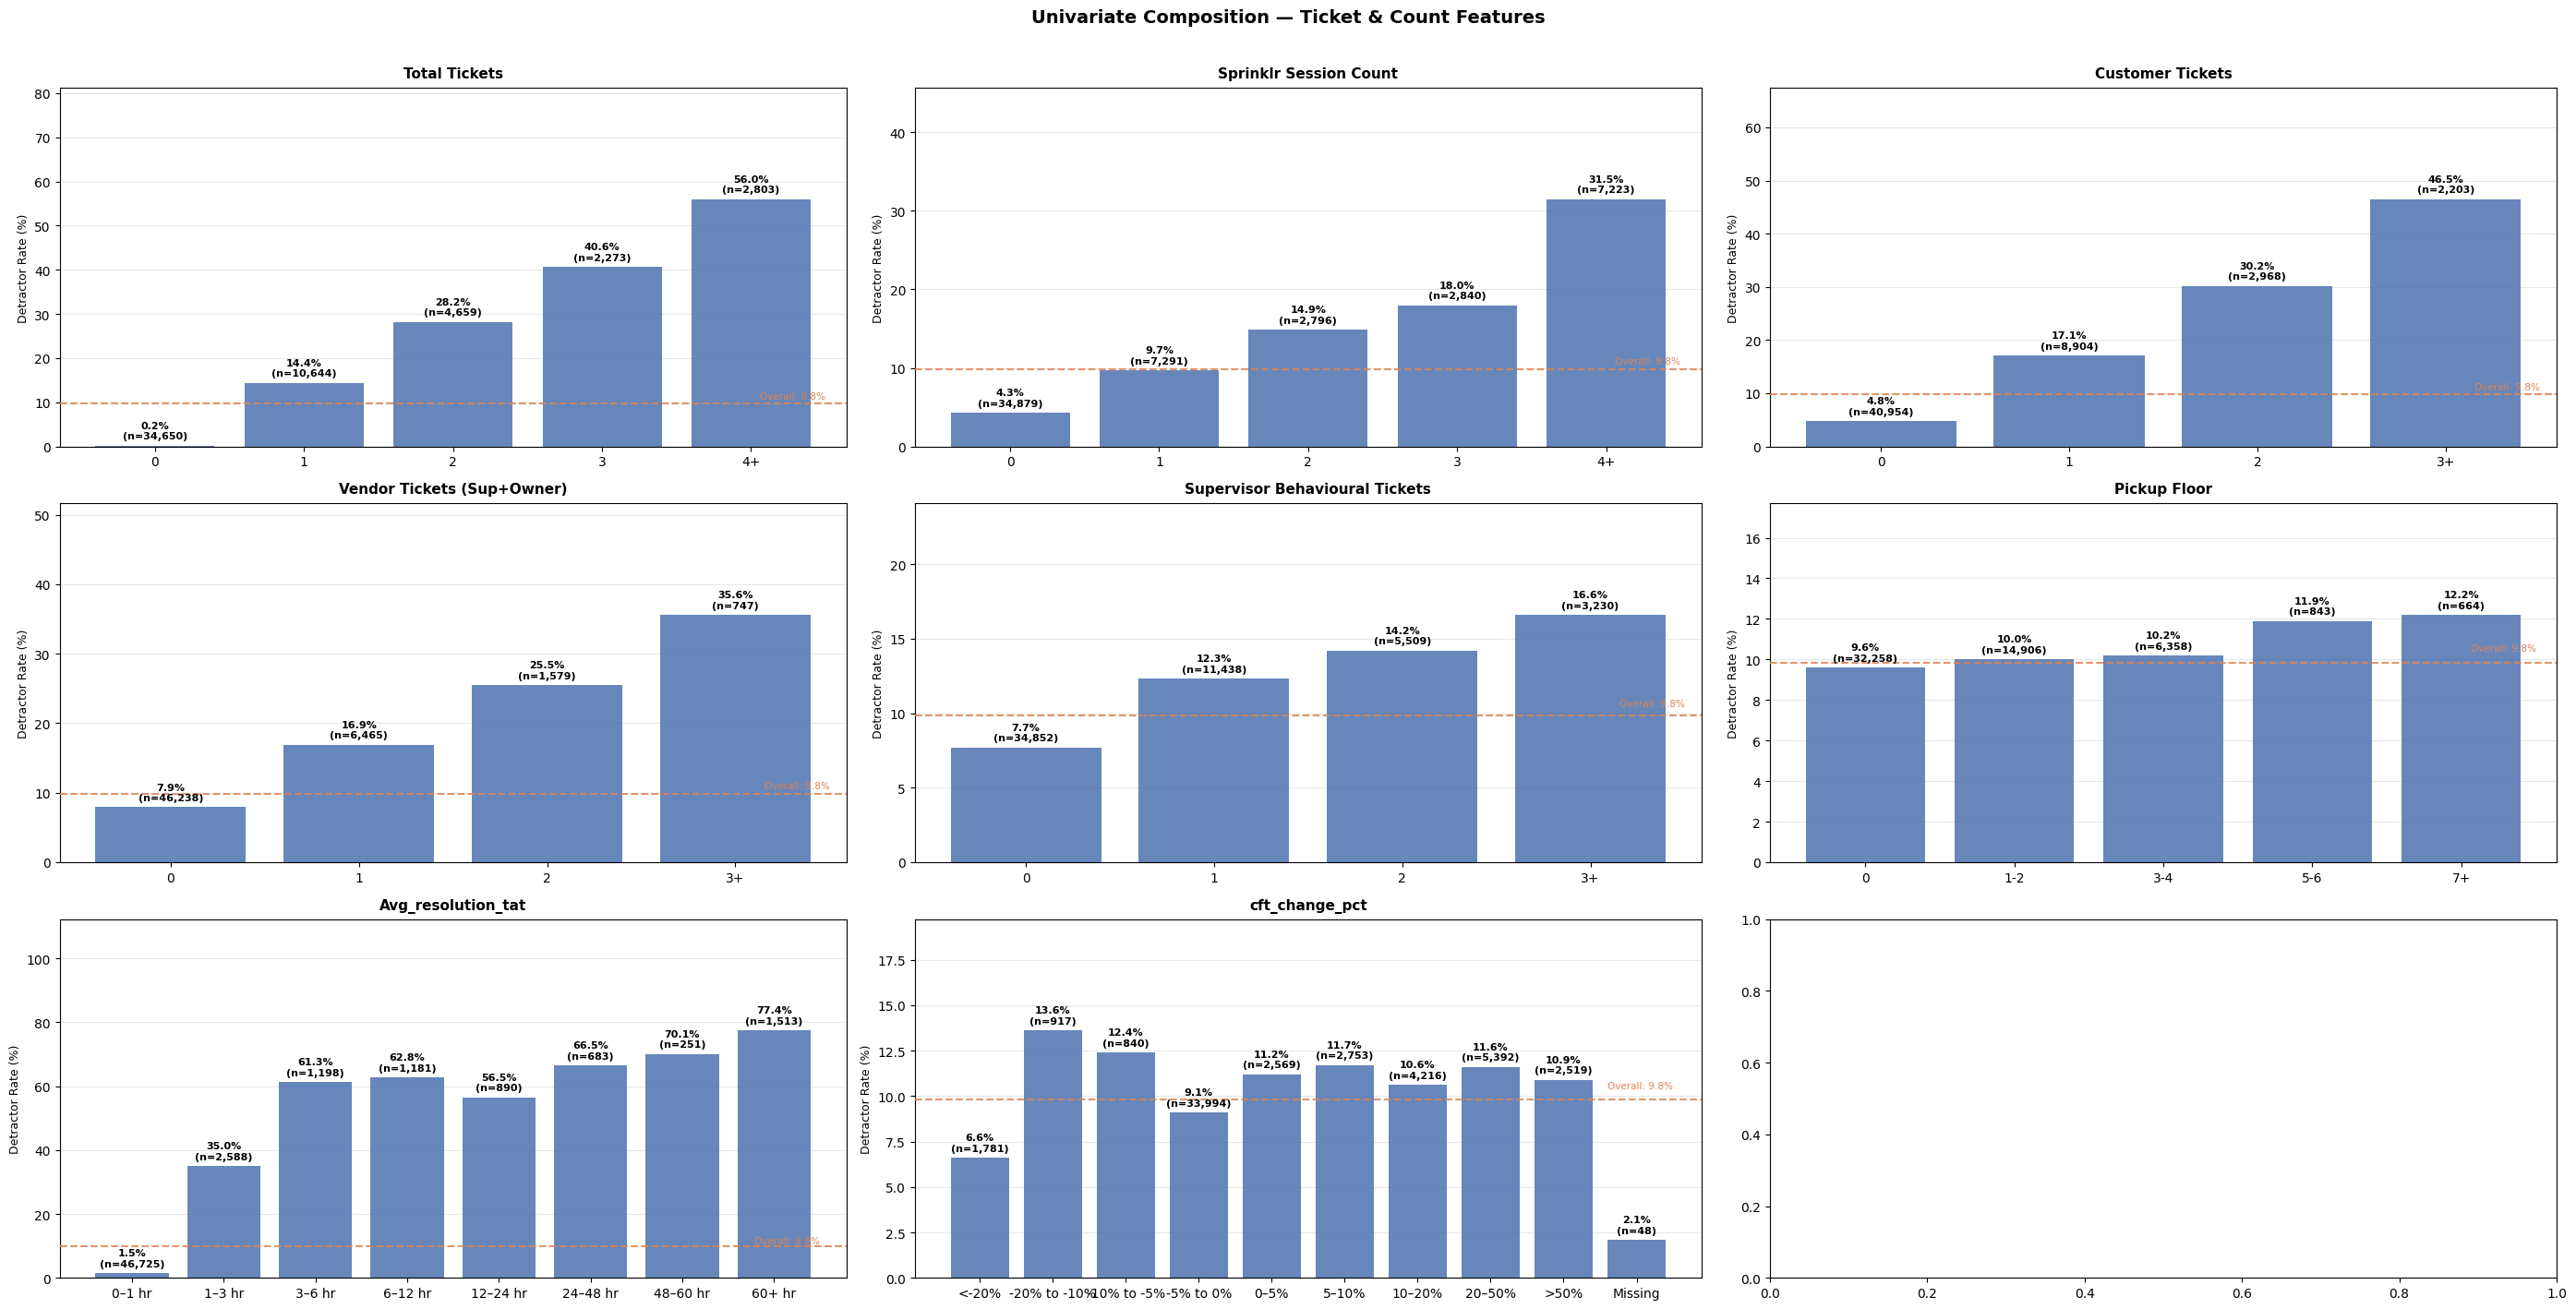

In [118]:
fig, axes = plt.subplots(3, 3, figsize=(28, 14))
fig.suptitle("Univariate Composition — Ticket & Count Features", fontsize=14, fontweight="bold", y=1.01)

univariate_bar(df["total_tickets_bin"],       "Total Tickets",                  axes[0,0])
univariate_bar(df["sprinklr_sessions_bin"],   "Sprinklr Session Count",         axes[0,1])
univariate_bar(df["customer_tickets_bin"],    "Customer Tickets",               axes[0,2])
univariate_bar(df["vendor_tickets_bin"],      "Vendor Tickets (Sup+Owner)",     axes[1,0])
univariate_bar(df["sup_bhv_bin"],             "Supervisor Behavioural Tickets", axes[1,1])
univariate_bar(df["floor_bin"],               "Pickup Floor",                   axes[1,2])
univariate_bar(df["resolution_tat_bin"], "Avg_resolution_tat", axes[2,0])
univariate_bar(df["cft_change_pct_bin"], "cft_change_pct", axes[2,1])
plt.tight_layout()
plt.show()


### 4.2 Order Characteristics — Continuous Features

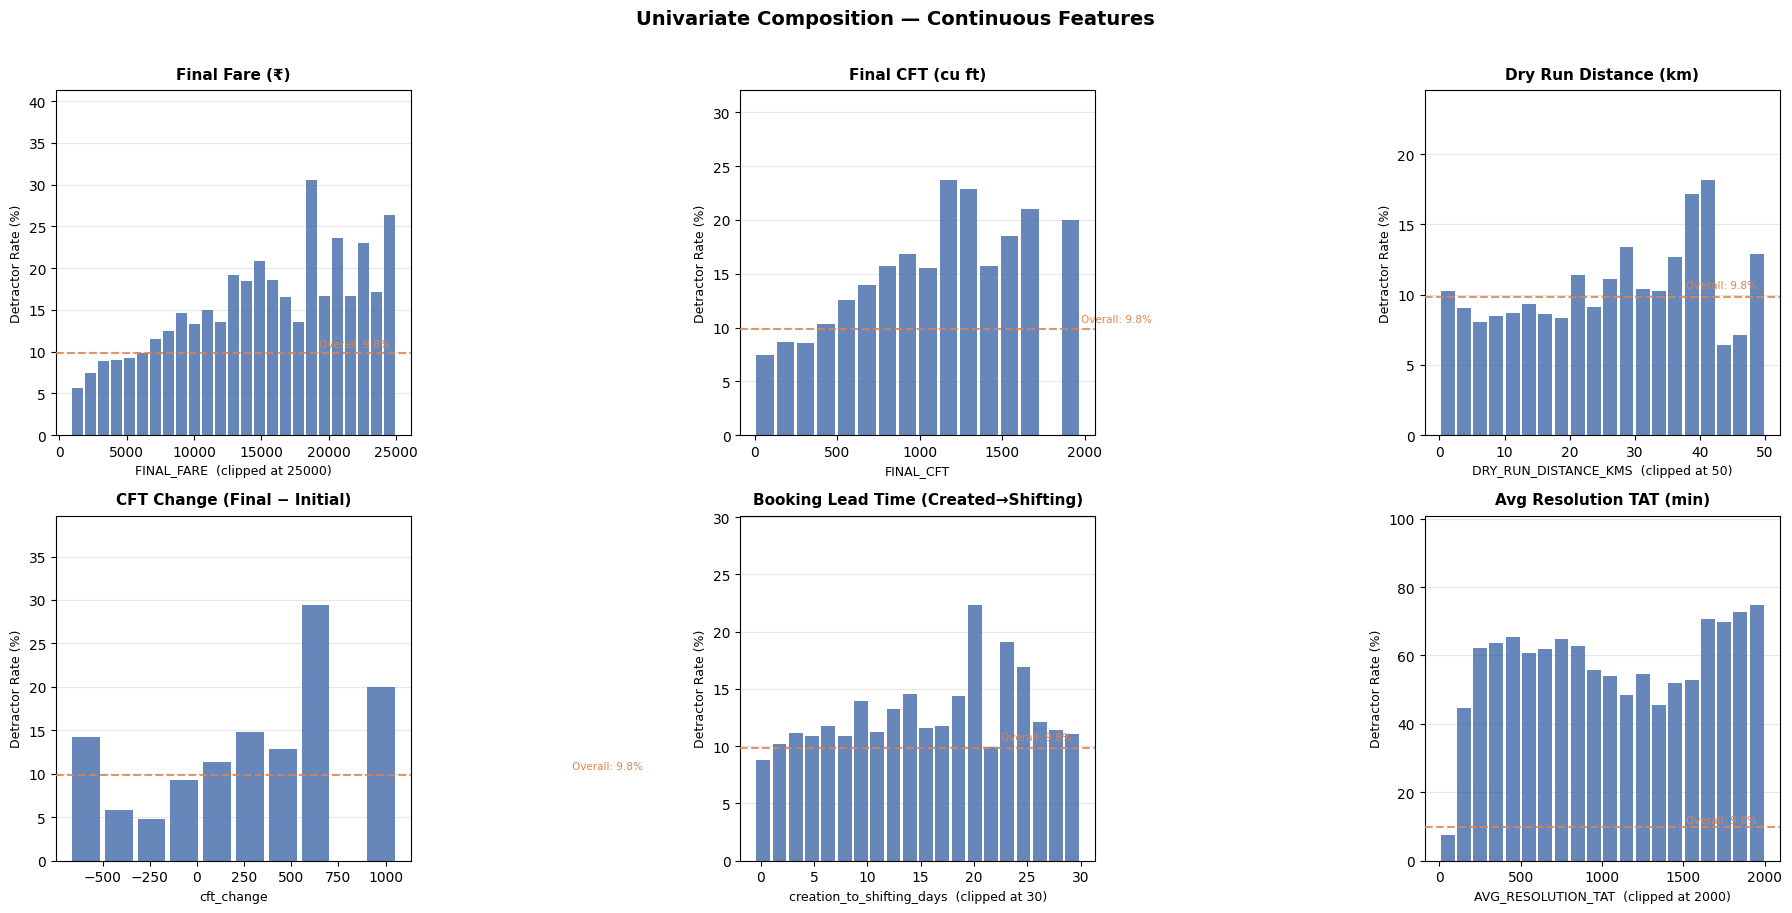

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle("Univariate Composition — Continuous Features", fontsize=14, fontweight="bold", y=1.01)

univariate_hist("FINAL_FARE",                "Final Fare (₹)",                       axes[0,0], bins=25, clip=25000)
univariate_hist("FINAL_CFT",                 "Final CFT (cu ft)",                    axes[0,1], bins=20)
univariate_hist("DRY_RUN_DISTANCE_KMS",      "Dry Run Distance (km)",                axes[0,2], bins=20, clip=50)
univariate_hist("cft_change",                "CFT Change (Final − Initial)",         axes[1,0], bins=20)
univariate_hist("creation_to_shifting_days", "Booking Lead Time (Created→Shifting)", axes[1,1], bins=20, clip=30)
univariate_hist("AVG_RESOLUTION_TAT",        "Avg Resolution TAT (min)",             axes[1,2], bins=20, clip=2000)

plt.tight_layout()
plt.show()


### 4.3 Categorical / Flag Features

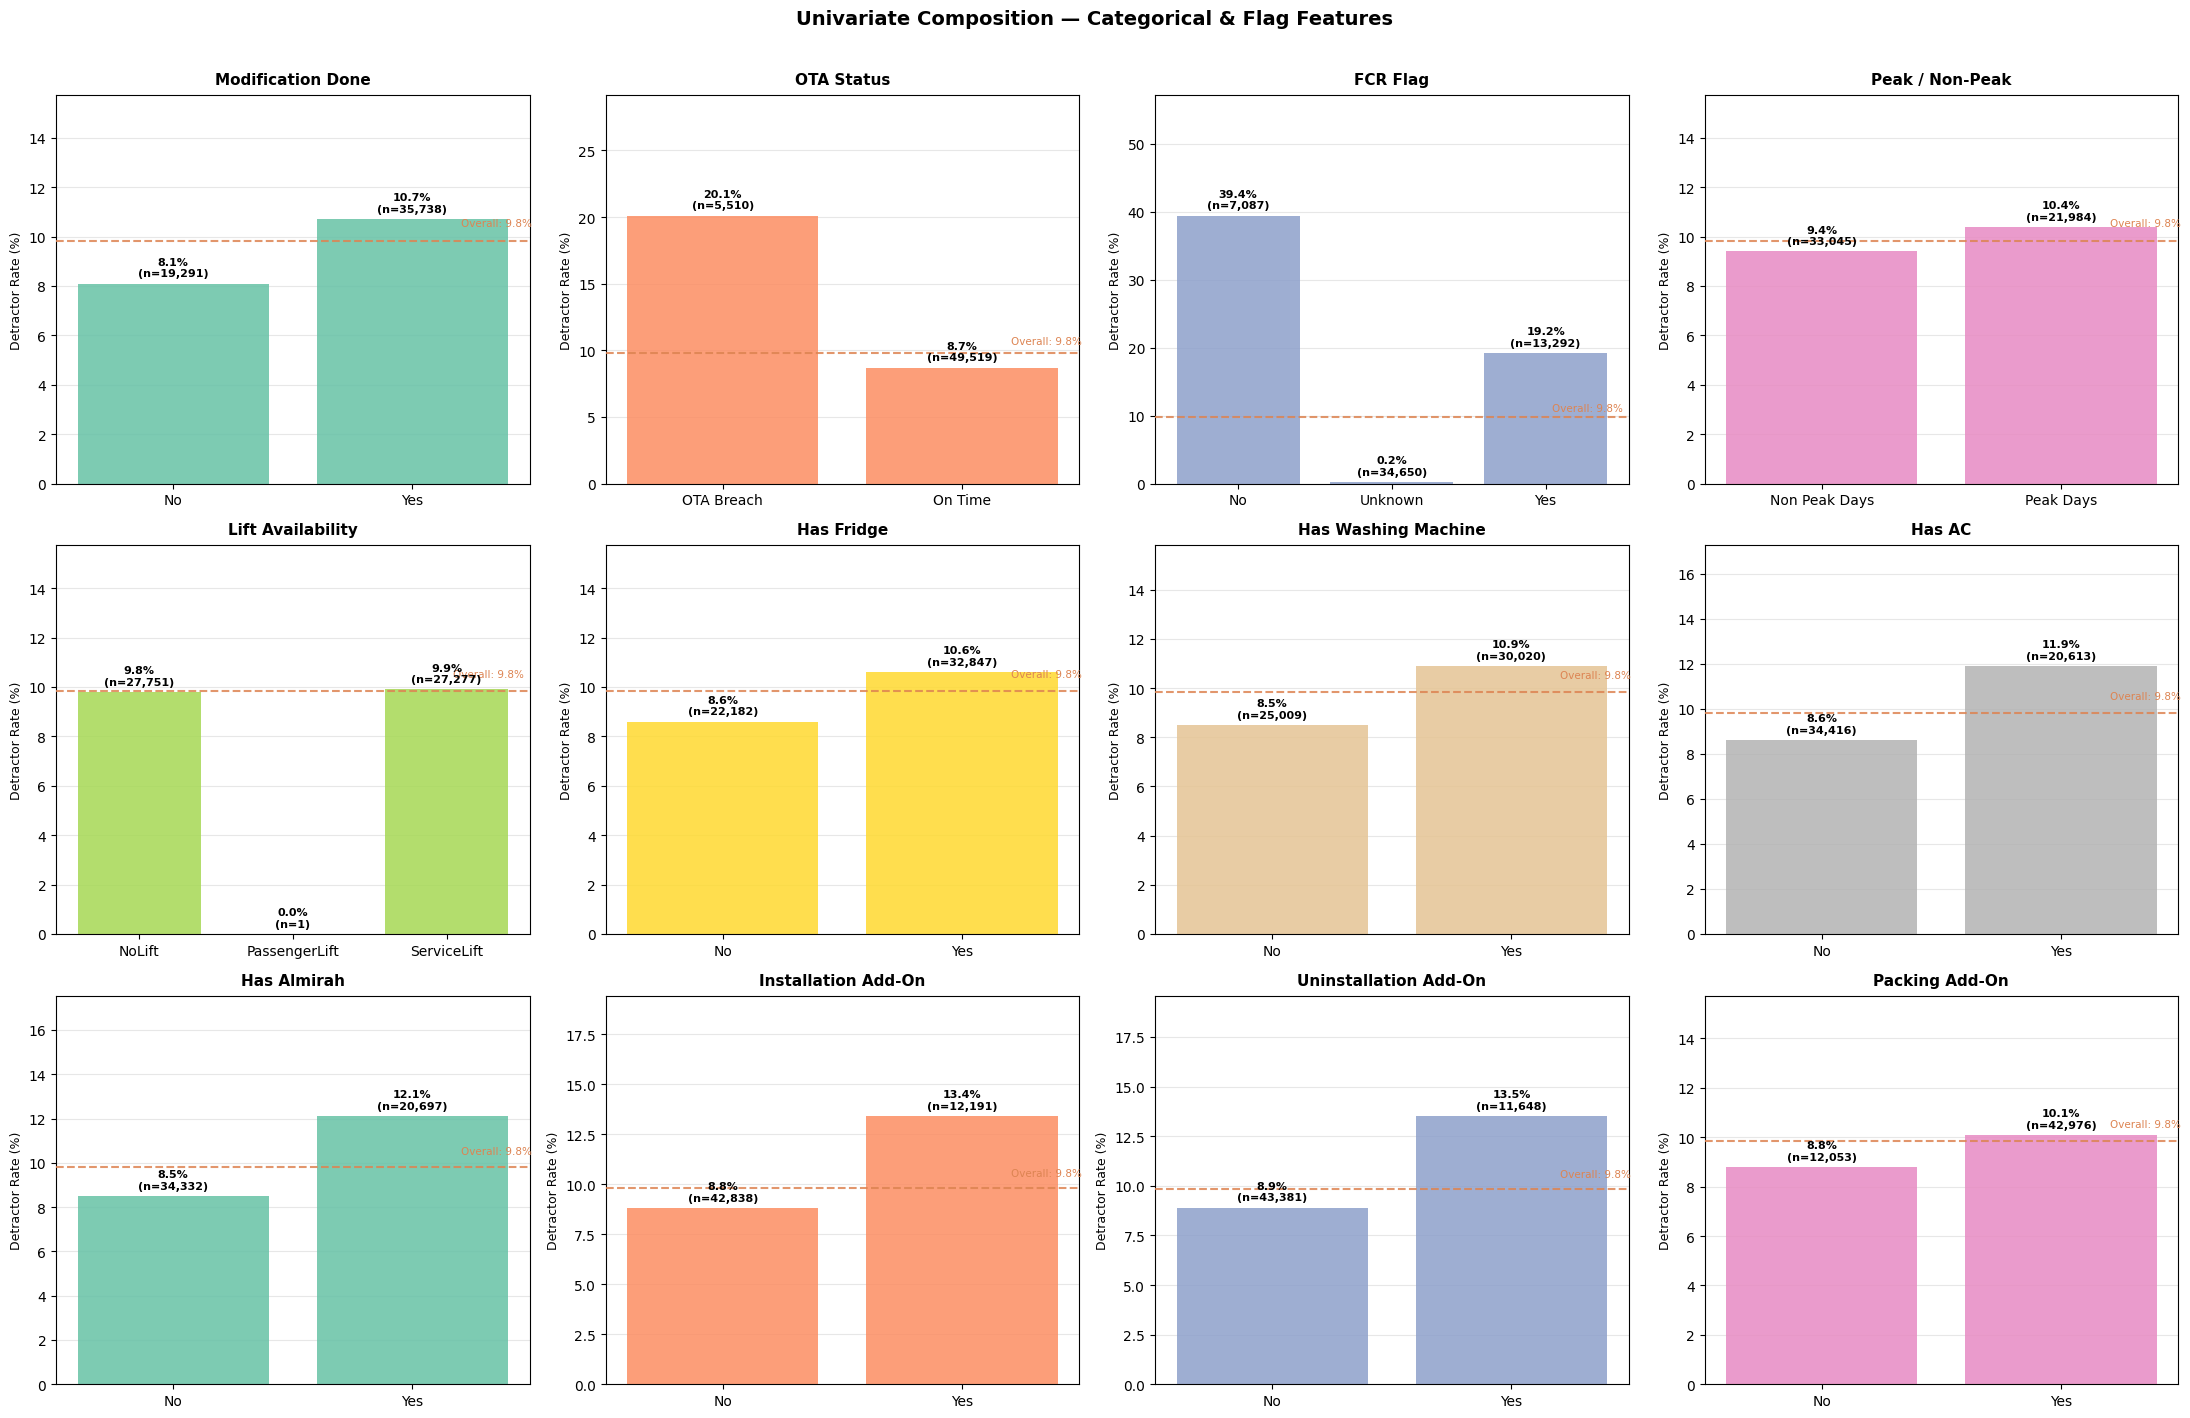

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(22, 14))
fig.suptitle("Univariate Composition — Categorical & Flag Features", fontsize=14, fontweight="bold", y=1.01)
axes = axes.flatten()

cat_features = [
    (df["IS_MODIFICATION_DONE"].fillna("Unknown").astype(str), "Modification Done"),
    (df["ota_binary"].fillna("Unknown").astype(str), "OTA Status"),
    (df["FIRST_CONTACT_RESOLUTION_FLAG"].fillna("Unknown").astype(str), "FCR Flag"),
    (df["PEAK_OR_NON_PEAK_DAYS"].fillna("Unknown").astype(str), "Peak / Non-Peak"),
    (df["PICKUP_LIFT_STATUS"].fillna("Unknown").astype(str), "Lift Availability"),
    (df["has_fridge"].map({1:"Yes",0:"No"}).fillna("Unknown"), "Has Fridge"),
    (df["has_washing_machine"].map({1:"Yes",0:"No"}).fillna("Unknown"), "Has Washing Machine"),
    (df["has_ac"].map({1:"Yes",0:"No"}).fillna("Unknown"), "Has AC"),
    (df["has_almirah"].map({1:"Yes",0:"No"}).fillna("Unknown"), "Has Almirah"),
    (df["has_installation"].map({1:"Yes",0:"No"}).fillna("Unknown"), "Installation Add-On"),
    (df["has_uninstallation"].map({1:"Yes",0:"No"}).fillna("Unknown"), "Uninstallation Add-On"),
    (df["has_packing"].map({1:"Yes",0:"No"}).fillna("Unknown"), "Packing Add-On"),
]

colors = sns.color_palette("Set2", len(cat_features))

for ax, (series, title), clr in zip(axes, cat_features, colors):
    univariate_bar(series.astype(str), title, ax=ax, color=clr)

# Hide unused axes
for ax in axes[len(cat_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

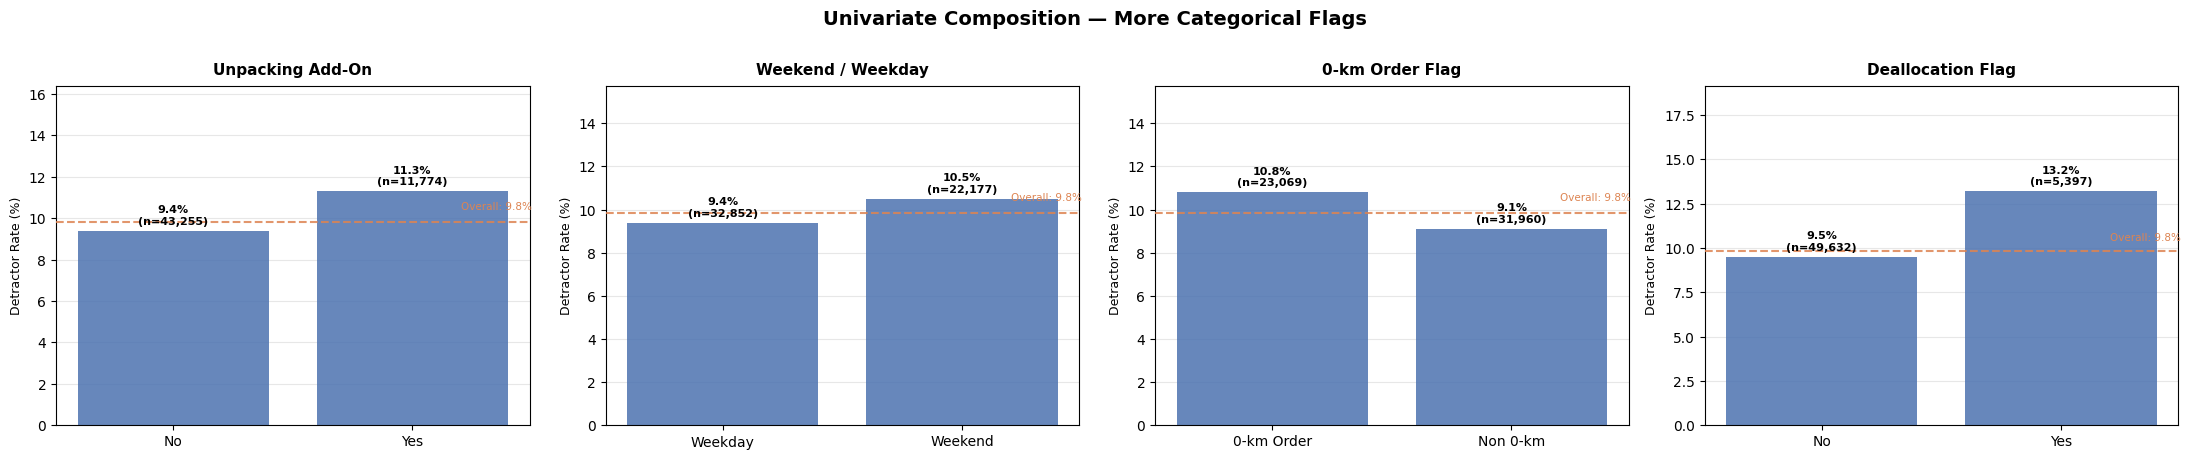

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
fig.suptitle("Univariate Composition — More Categorical Flags", fontsize=14, fontweight="bold", y=1.01)

univariate_bar(df["has_unpacking"].map({1:"Yes",0:"No"}),    "Unpacking Add-On",             axes[0])
univariate_bar(df["weekend_flag"],                            "Weekend / Weekday",             axes[1])
univariate_bar(df["zero_km_flag"],                            "0-km Order Flag",               axes[2])
univariate_bar(df["DEALLOCATION_STATUS"].map({True:"Yes",False:"No"}), "Deallocation Flag",   axes[3])

plt.tight_layout()
plt.show()

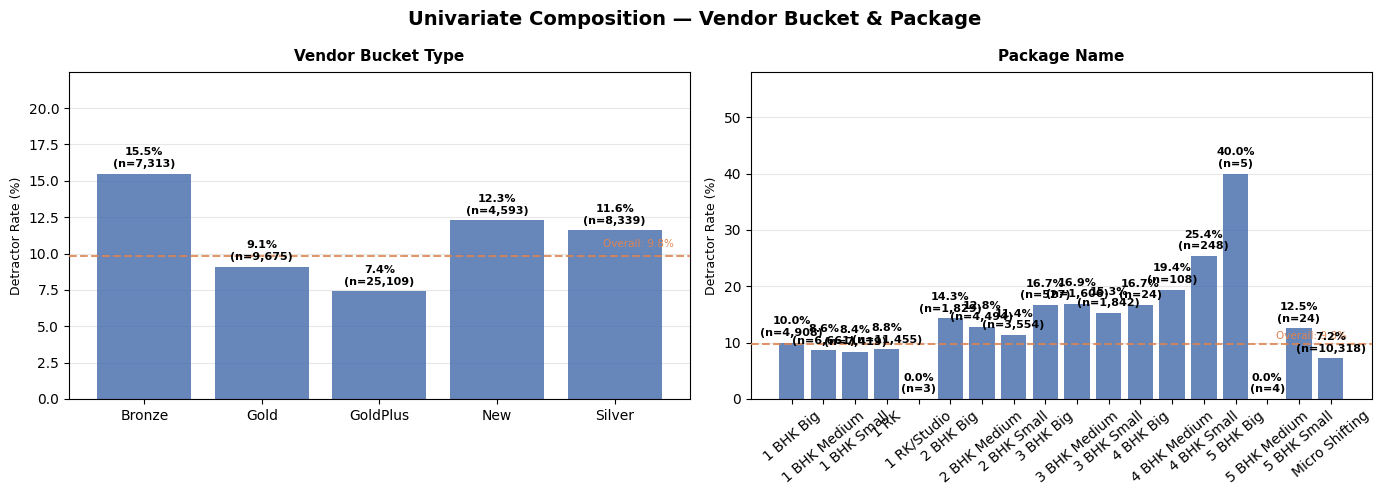

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Univariate Composition — Vendor Bucket & Package", fontsize=14, fontweight="bold")

univariate_bar(df["VENDOR_BUCKET_TYPE"], "Vendor Bucket Type", axes[0])
univariate_bar(df["PACKAGE_NAME"],       "Package Name",        axes[1], rotate=40)

plt.tight_layout()
plt.show()

## 5. Multivariate Composition Analysis (Feature Intersections)

Each stacked bar chart shows how detractor orders are distributed across the **intersection** of two features.  
Bars are coloured by the second feature; annotations show total count and **% of all detractors** per bar.

In [ ]:
def barplot_intersection(
    df, row_col, col_col,
    row_label=None, col_label=None,
    title=None, ax=None, figsize=(11, 5)
):
    """
    Stacked bar chart showing the count intersection of two categorical features.
    X-axis = row_col categories; bars stacked/coloured by col_col categories.
    Bars are annotated with total count and % of all detractors.
    """
    pivot = pd.crosstab(df[row_col], df[col_col])
    total = len(df)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)

    colors = sns.color_palette("Set2", pivot.shape[1])
    pivot.plot(kind="bar", stacked=True, ax=ax, color=colors,
               edgecolor="white", alpha=0.88, zorder=2)

    # Annotate each bar with total count + % of all detractors
    row_totals = pivot.sum(axis=1)
    for i, tot in enumerate(row_totals.values):
        pct = tot / total * 100
        ax.text(
            i, tot + total * 0.004,
            f"{tot:,}  ({pct:.1f}%)",
            ha="center", va="bottom", fontsize=7.5, fontweight="bold"
        )

    ax.set_title(title or f"{row_col}  ×  {col_col}", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel(row_label or row_col, fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.tick_params(axis="x", rotation=35)
    ax.legend(
        title=col_label or col_col,
        bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8
    )
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

    if standalone:
        plt.tight_layout()
        plt.show()

print("Helper function `barplot_intersection` ready ")

Helper function `barplot_intersection` ready 


In [ ]:
# Detractors-only subset — used for all Section 5 composition cross-tabs
detractors = responses_data[responses_data["is_detractor"] == 1].copy()
print(f"Detractors for cross-tab analysis: {len(detractors):,} orders")


Detractors for cross-tab analysis: 5,409 orders


### 5.1 Vendor Bucket × Lift Availability & Floor

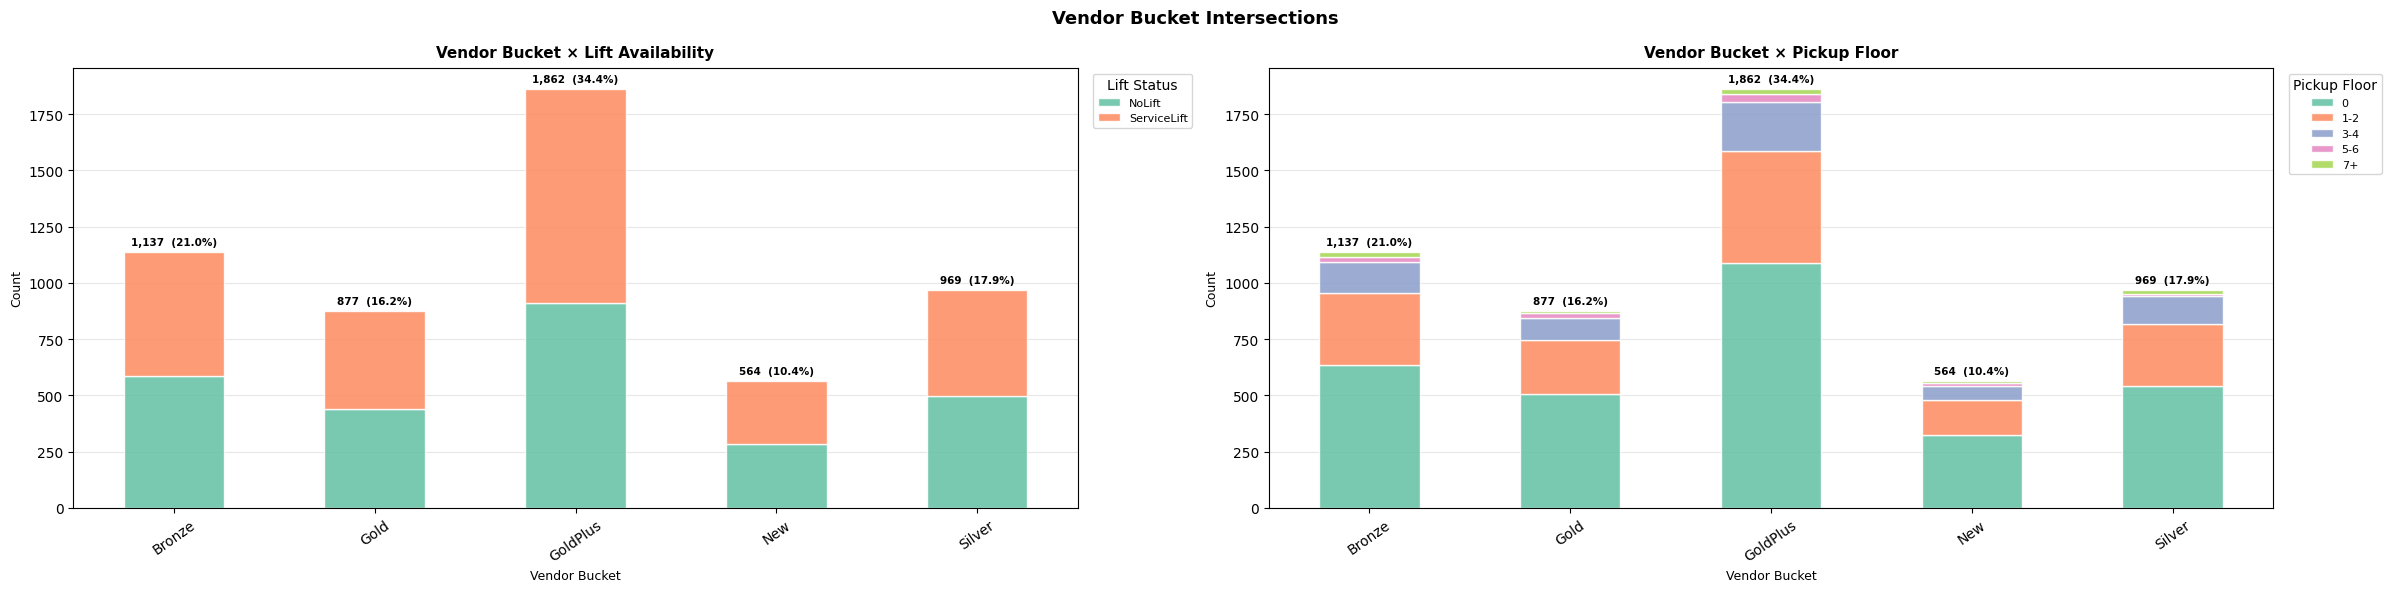

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 6))
fig.suptitle("Vendor Bucket Intersections", fontsize=13, fontweight="bold")

barplot_intersection(
    detractors, "VENDOR_BUCKET_TYPE", "PICKUP_LIFT_STATUS",
    row_label="Vendor Bucket", col_label="Lift Status",
    title="Vendor Bucket × Lift Availability", ax=axes[0]
)
barplot_intersection(
    detractors, "VENDOR_BUCKET_TYPE", "floor_bin",
    row_label="Vendor Bucket", col_label="Pickup Floor",
    title="Vendor Bucket × Pickup Floor", ax=axes[1]
)
plt.tight_layout()
plt.show()


### 5.2 Peak/Non-Peak × OTA, FCR & Modification

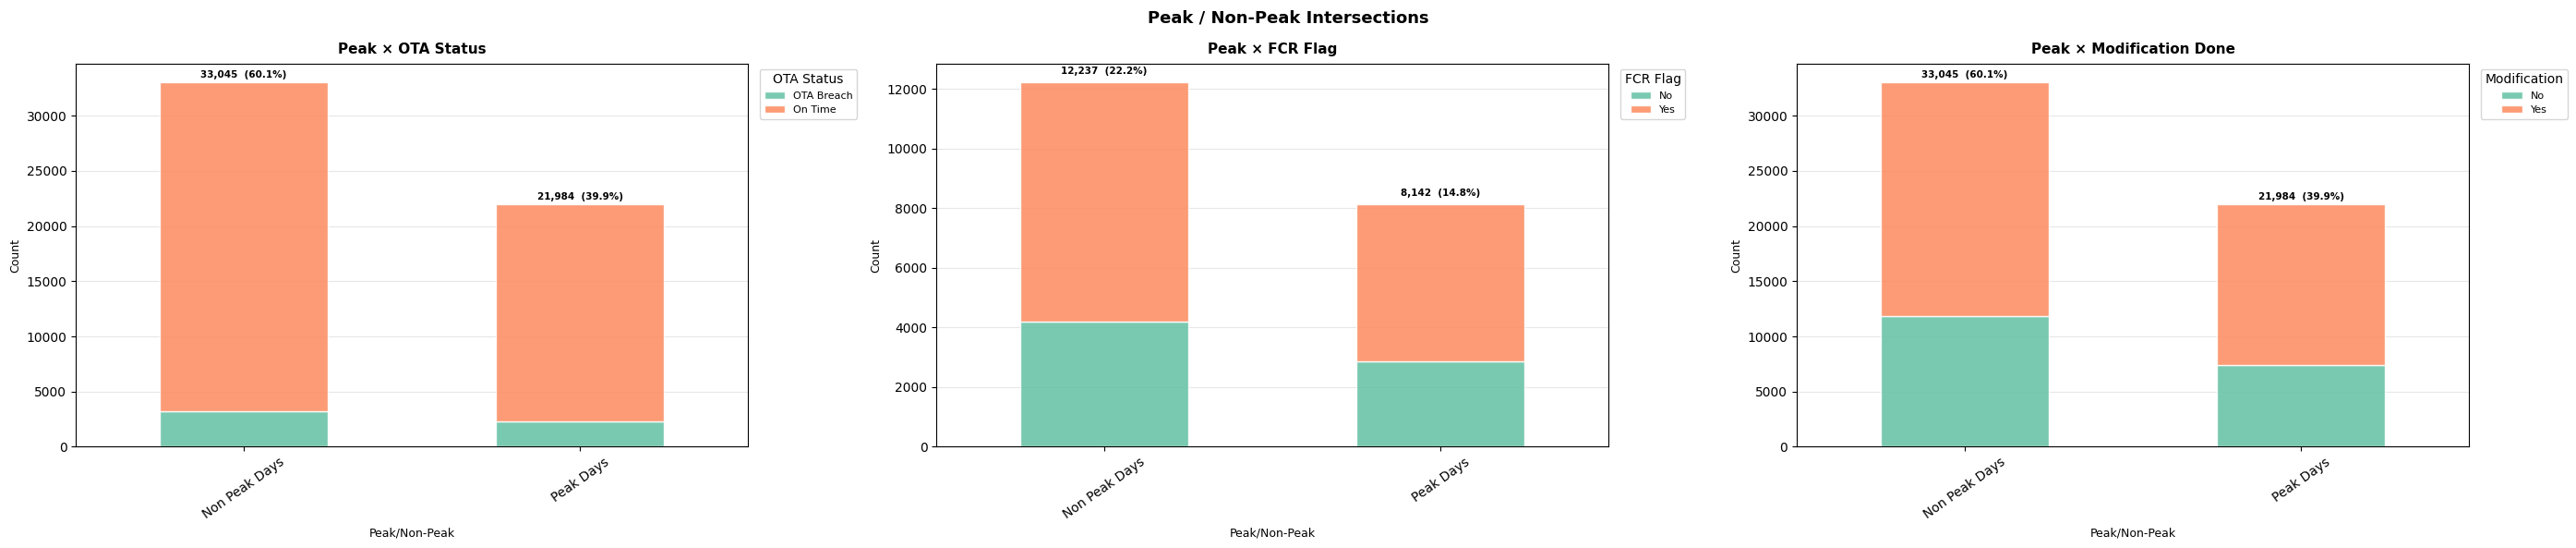

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(28, 6))
fig.suptitle("Peak / Non-Peak Intersections", fontsize=13, fontweight="bold")

barplot_intersection(df, "PEAK_OR_NON_PEAK_DAYS", "ota_binary",
    row_label="Peak/Non-Peak", col_label="OTA Status",
    title="Peak × OTA Status", ax=axes[0])
barplot_intersection(df, "PEAK_OR_NON_PEAK_DAYS", "FIRST_CONTACT_RESOLUTION_FLAG",
    row_label="Peak/Non-Peak", col_label="FCR Flag",
    title="Peak × FCR Flag", ax=axes[1])
barplot_intersection(df, "PEAK_OR_NON_PEAK_DAYS", "IS_MODIFICATION_DONE",
    row_label="Peak/Non-Peak", col_label="Modification",
    title="Peak × Modification Done", ax=axes[2])

plt.tight_layout()
plt.show()

### 5.3 Ticket Load Intersections (Total, Customer, Vendor)

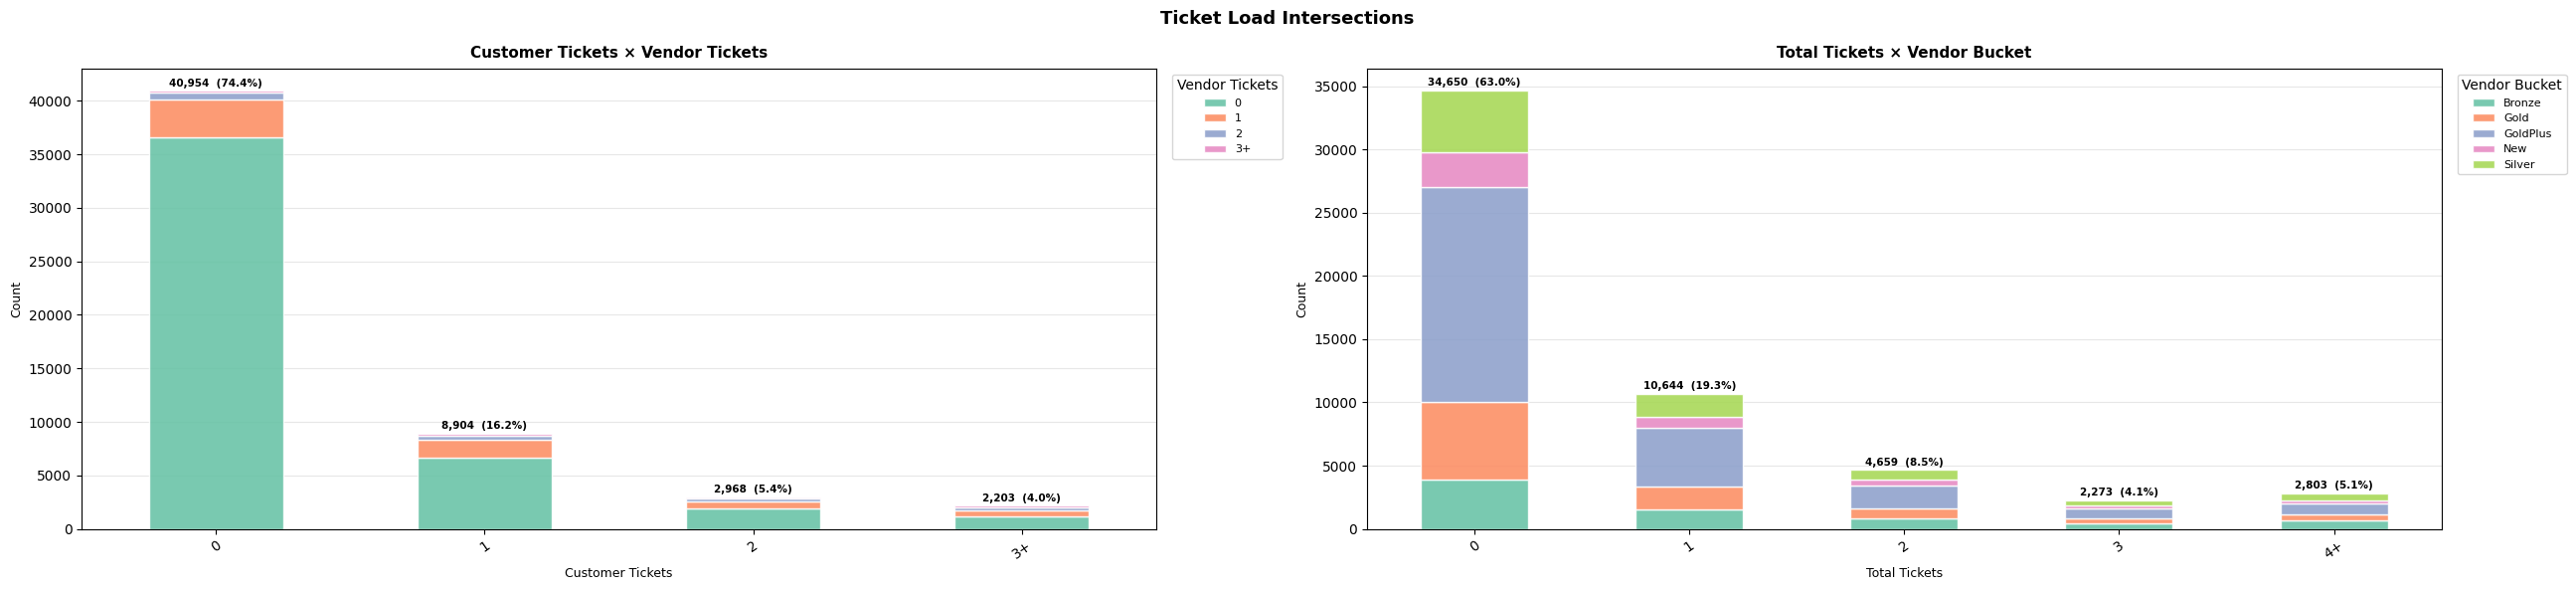

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(26, 6))
fig.suptitle("Ticket Load Intersections", fontsize=13, fontweight="bold")

barplot_intersection(df, "customer_tickets_bin", "vendor_tickets_bin",
    row_label="Customer Tickets", col_label="Vendor Tickets",
    title="Customer Tickets × Vendor Tickets", ax=axes[0])
barplot_intersection(df, "total_tickets_bin", "VENDOR_BUCKET_TYPE",
    row_label="Total Tickets", col_label="Vendor Bucket",
    title="Total Tickets × Vendor Bucket", ax=axes[1])

plt.tight_layout()
plt.show()

### 5.4 Physical Complexity — Floor × Lift × Dry-Run Distance

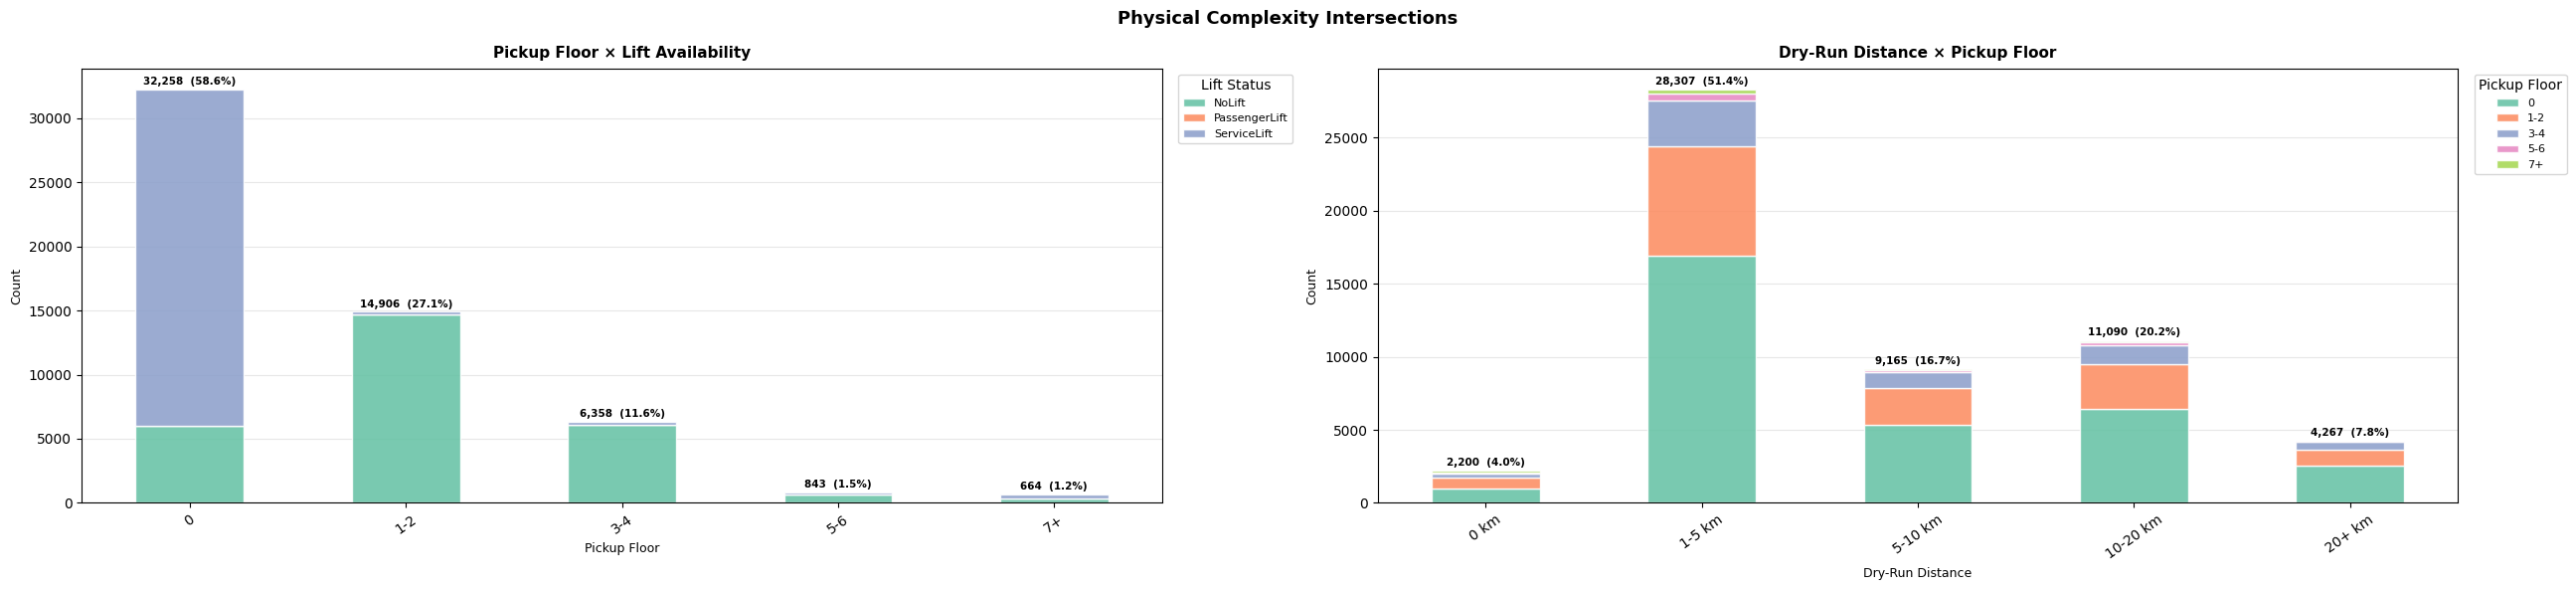

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(26, 6))
fig.suptitle("Physical Complexity Intersections", fontsize=13, fontweight="bold")

barplot_intersection(df, "floor_bin", "PICKUP_LIFT_STATUS",
    row_label="Pickup Floor", col_label="Lift Status",
    title="Pickup Floor × Lift Availability", ax=axes[0])
barplot_intersection(df, "dry_run_bin", "floor_bin",
    row_label="Dry-Run Distance", col_label="Pickup Floor",
    title="Dry-Run Distance × Pickup Floor", ax=axes[1])

plt.tight_layout()
plt.show()

### 5.5 Fare & CFT Intersections

KeyError: 'cft_change_bin'

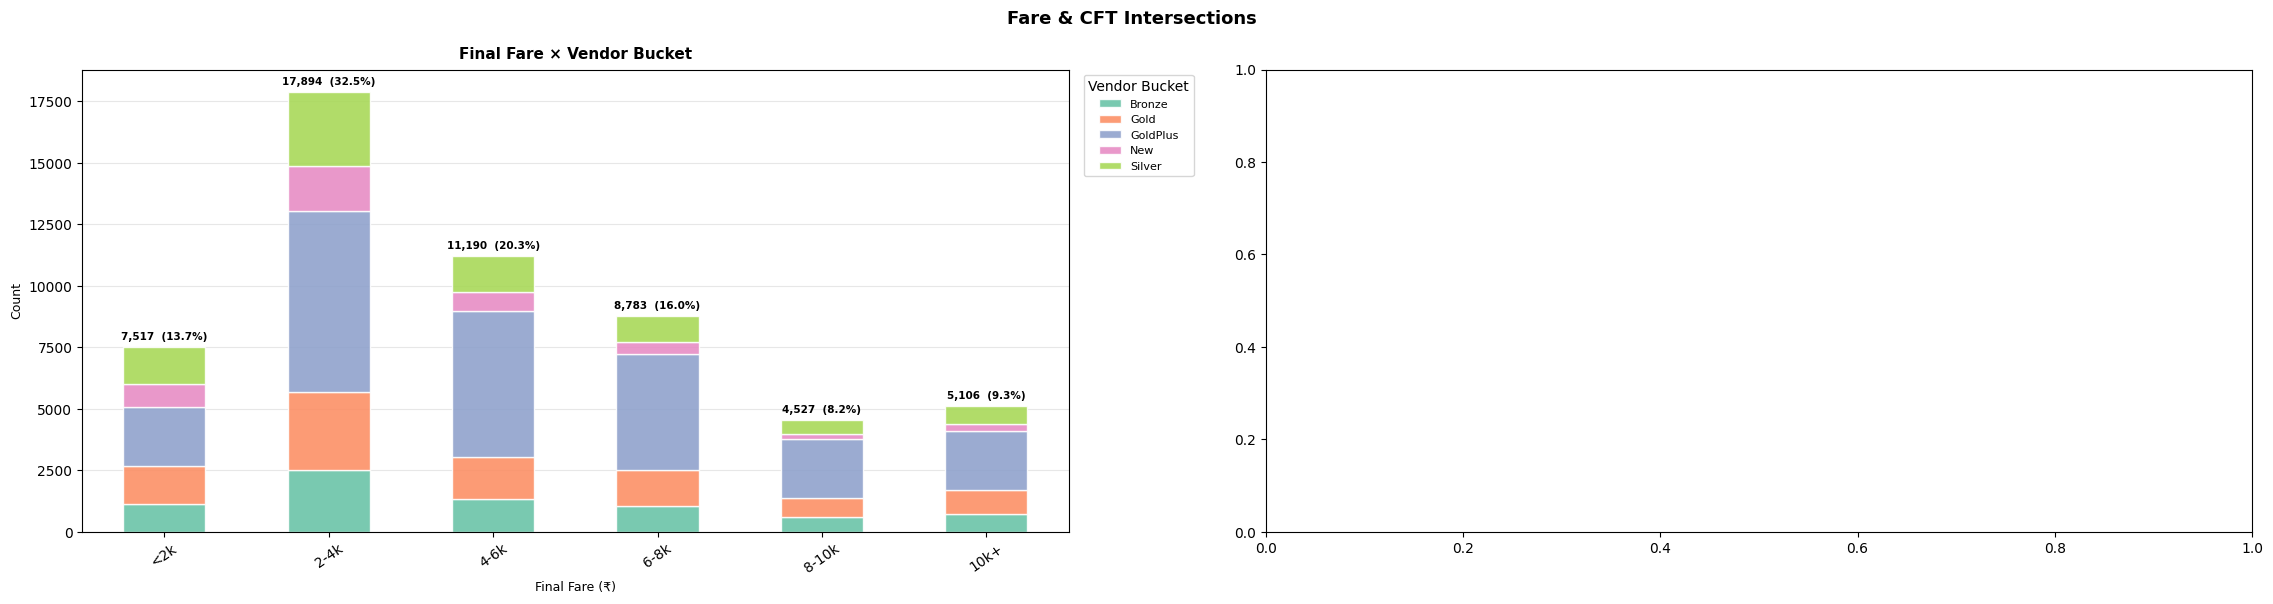

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(28, 6))
fig.suptitle("Fare & CFT Intersections", fontsize=13, fontweight="bold")

barplot_intersection(df, "final_fare_bin", "VENDOR_BUCKET_TYPE",
    row_label="Final Fare (₹)", col_label="Vendor Bucket",
    title="Final Fare × Vendor Bucket", ax=axes[0])
barplot_intersection(df, "final_cft_bin", "cft_change_bin",
    row_label="Final CFT (cu ft)", col_label="CFT Change",
    title="Final CFT × CFT Change", ax=axes[1])

plt.tight_layout()
plt.show()

### 5.6 Item Flags Intersection Matrix (Fridge, WM, AC, Almirah)

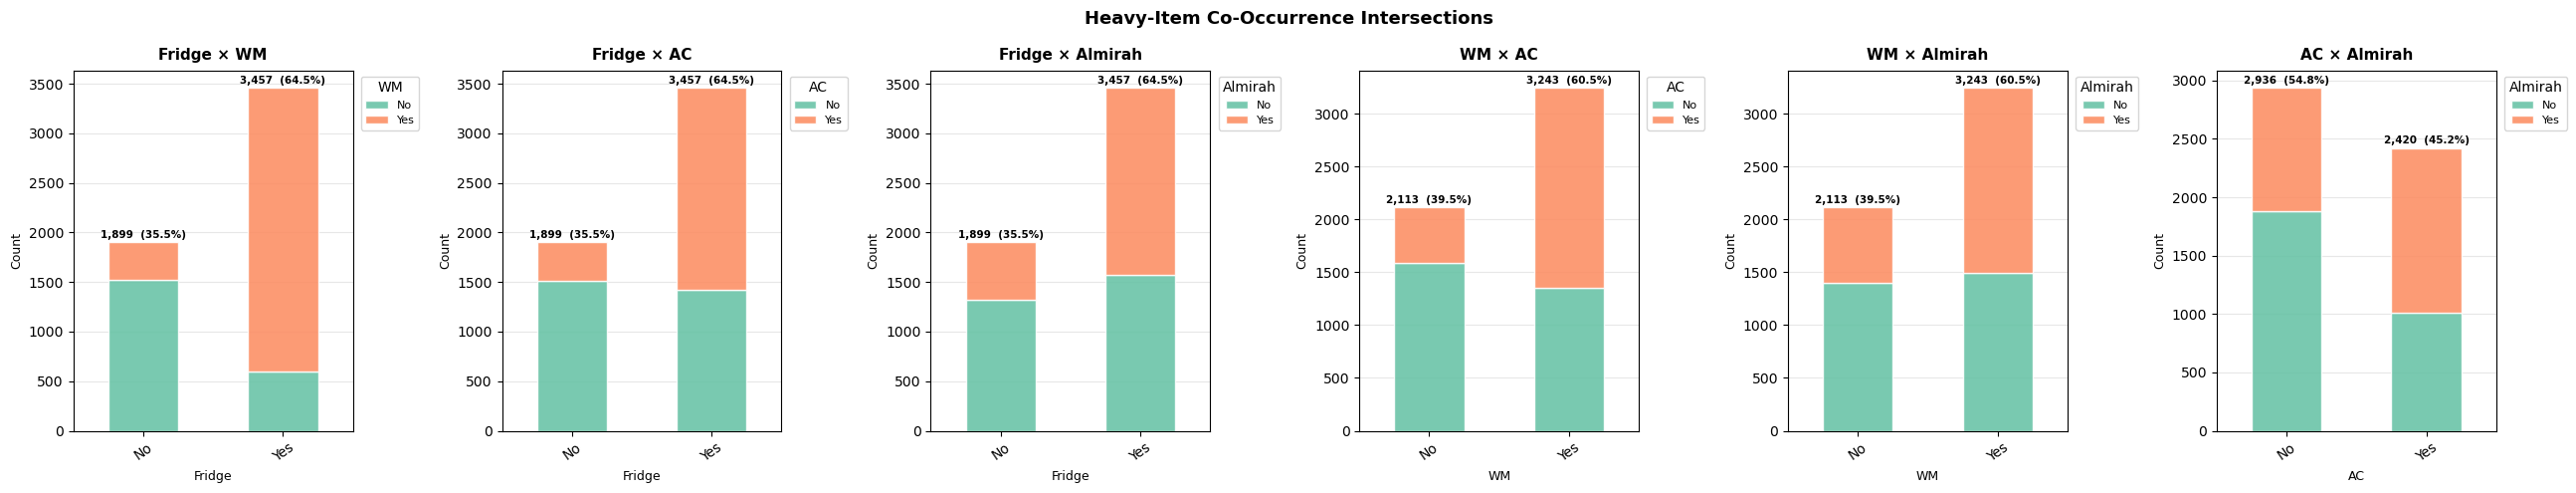

In [ ]:
item_pairs = list(combinations(["has_fridge","has_washing_machine","has_ac","has_almirah"], 2))
labels_map = {
    "has_fridge": "Fridge", "has_washing_machine": "WM",
    "has_ac": "AC", "has_almirah": "Almirah"
}

fig, axes = plt.subplots(1, len(item_pairs), figsize=(26, 5))
fig.suptitle("Heavy-Item Co-Occurrence Intersections", fontsize=13, fontweight="bold")

for ax, (c1, c2) in zip(axes, item_pairs):
    tmp1 = f"_tmp_{c1}"
    tmp2 = f"_tmp_{c2}"
    df[tmp1] = df[c1].map({1: "Yes", 0: "No"})
    df[tmp2] = df[c2].map({1: "Yes", 0: "No"})
    barplot_intersection(
        df, tmp1, tmp2,
        row_label=labels_map[c1], col_label=labels_map[c2],
        title=f"{labels_map[c1]} × {labels_map[c2]}", ax=ax
    )
    df.drop(columns=[tmp1, tmp2], inplace=True)

plt.tight_layout()
plt.show()

### 5.7 Booking Lead Time × Peak, Vendor Bucket & Weekend

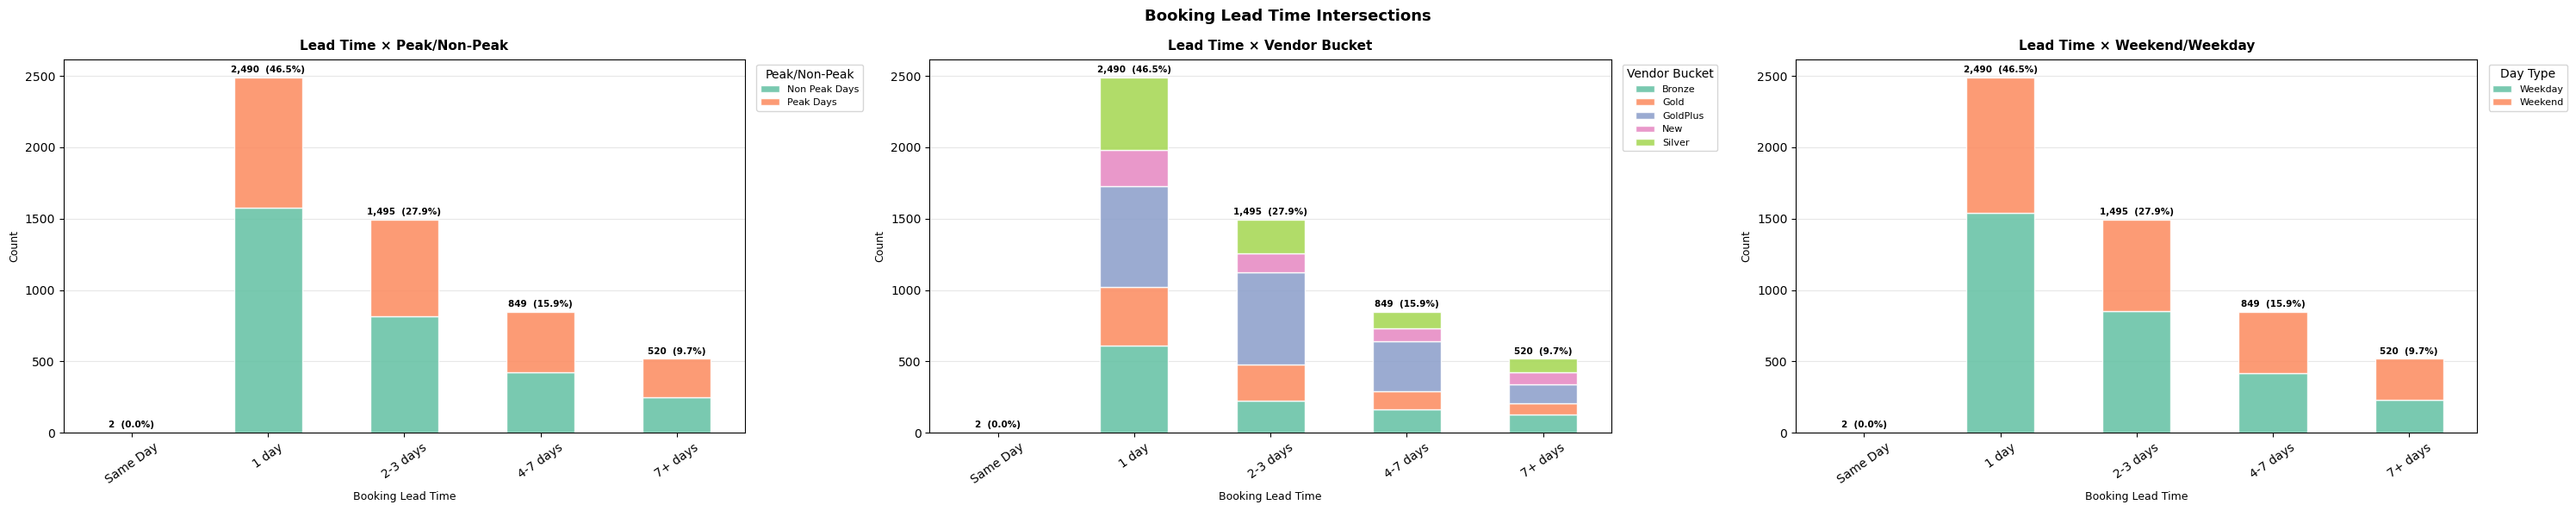

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(30, 6))
fig.suptitle("Booking Lead Time Intersections", fontsize=13, fontweight="bold")

barplot_intersection(df, "booking_lead_bin", "PEAK_OR_NON_PEAK_DAYS",
    row_label="Booking Lead Time", col_label="Peak/Non-Peak",
    title="Lead Time × Peak/Non-Peak", ax=axes[0])
barplot_intersection(df, "booking_lead_bin", "VENDOR_BUCKET_TYPE",
    row_label="Booking Lead Time", col_label="Vendor Bucket",
    title="Lead Time × Vendor Bucket", ax=axes[1])
barplot_intersection(df, "booking_lead_bin", "weekend_flag",
    row_label="Booking Lead Time", col_label="Day Type",
    title="Lead Time × Weekend/Weekday", ax=axes[2])

plt.tight_layout()
plt.show()

### 5.8 3-Way Intersection — Vendor Bucket × Peak × FCR

Group-level stacked bars showing the FCR composition within each (Vendor Bucket, Peak) segment.

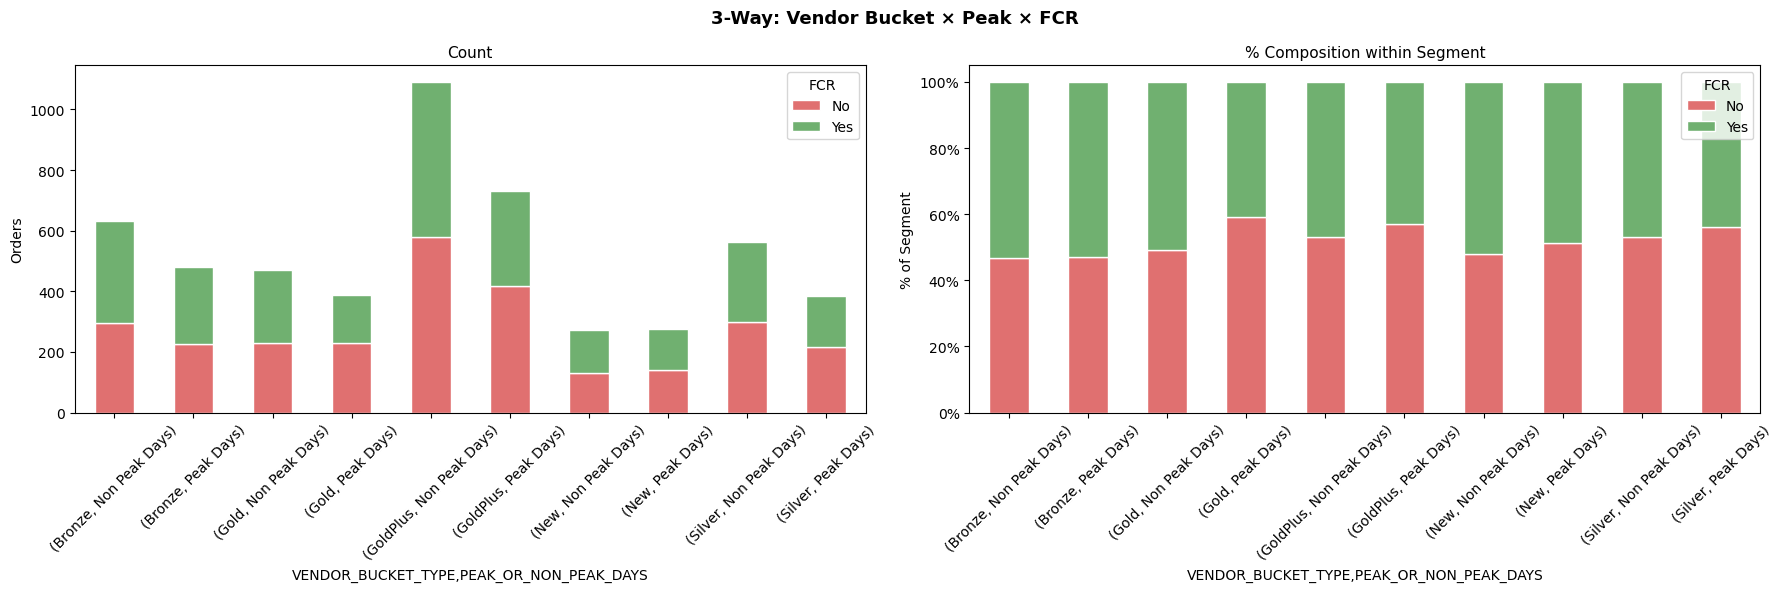

In [ ]:
grp = (
    df.groupby(["VENDOR_BUCKET_TYPE", "PEAK_OR_NON_PEAK_DAYS", "FIRST_CONTACT_RESOLUTION_FLAG"])
    .size()
    .reset_index(name="count")
)
pivot3 = grp.pivot_table(
    index=["VENDOR_BUCKET_TYPE", "PEAK_OR_NON_PEAK_DAYS"],
    columns="FIRST_CONTACT_RESOLUTION_FLAG",
    values="count",
    fill_value=0
)

# % within each (Vendor, Peak) group
pivot3_pct = pivot3.div(pivot3.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("3-Way: Vendor Bucket × Peak × FCR", fontsize=13, fontweight="bold")

pivot3.plot(kind="bar", stacked=True, ax=axes[0],
            color=["#e07070","#70b070"], edgecolor="white")
axes[0].set_title("Count", fontsize=11)
axes[0].set_ylabel("Orders")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="FCR")

pivot3_pct.plot(kind="bar", stacked=True, ax=axes[1],
                color=["#e07070","#70b070"], edgecolor="white")
axes[1].set_title("% Composition within Segment", fontsize=11)
axes[1].set_ylabel("% of Segment")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="FCR")

plt.tight_layout()
plt.show()

### 5.9 3-Way — Lift × Floor × Vendor Bucket

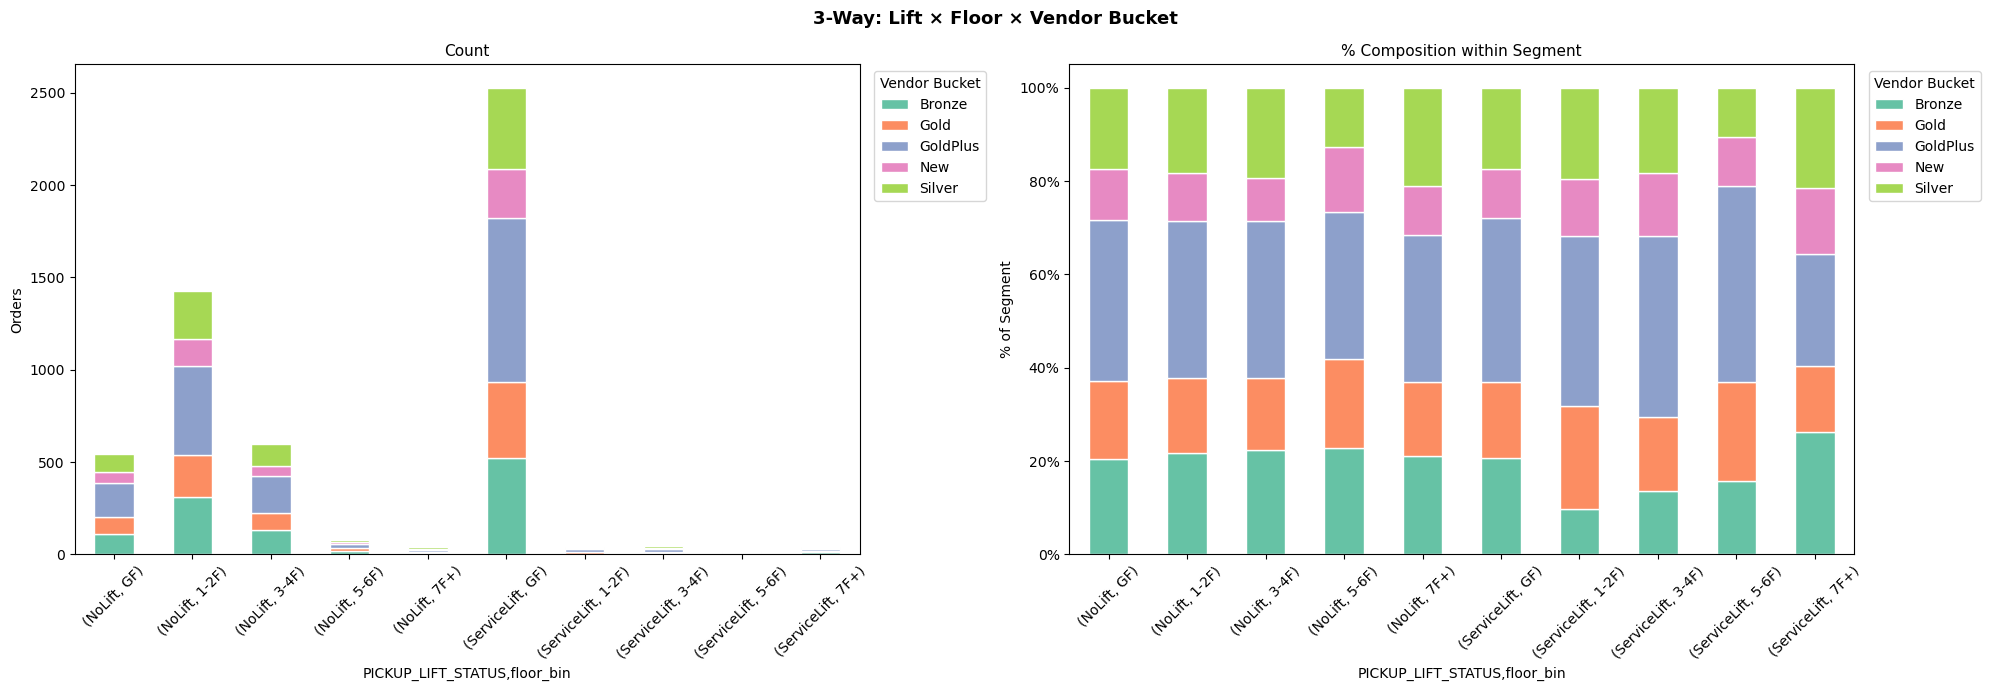

In [ ]:
grp2 = (
    df.groupby(["PICKUP_LIFT_STATUS", "floor_bin", "VENDOR_BUCKET_TYPE"])
    .size()
    .reset_index(name="count")
)
pivot_lift_floor = grp2.pivot_table(
    index=["PICKUP_LIFT_STATUS", "floor_bin"],
    columns="VENDOR_BUCKET_TYPE",
    values="count",
    fill_value=0
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("3-Way: Lift × Floor × Vendor Bucket", fontsize=13, fontweight="bold")

bucket_colors = sns.color_palette("Set2", 5)

pivot_lift_floor.plot(kind="bar", stacked=True, ax=axes[0],
                      color=bucket_colors, edgecolor="white")
axes[0].set_title("Count", fontsize=11)
axes[0].set_ylabel("Orders")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Vendor Bucket", bbox_to_anchor=(1.01, 1), loc="upper left")

pivot_lift_floor_pct = pivot_lift_floor.div(pivot_lift_floor.sum(axis=1), axis=0) * 100
pivot_lift_floor_pct.plot(kind="bar", stacked=True, ax=axes[1],
                          color=bucket_colors, edgecolor="white")
axes[1].set_title("% Composition within Segment", fontsize=11)
axes[1].set_ylabel("% of Segment")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Vendor Bucket", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

### 5.10 Deallocation & Both-Ticket Flag Intersections

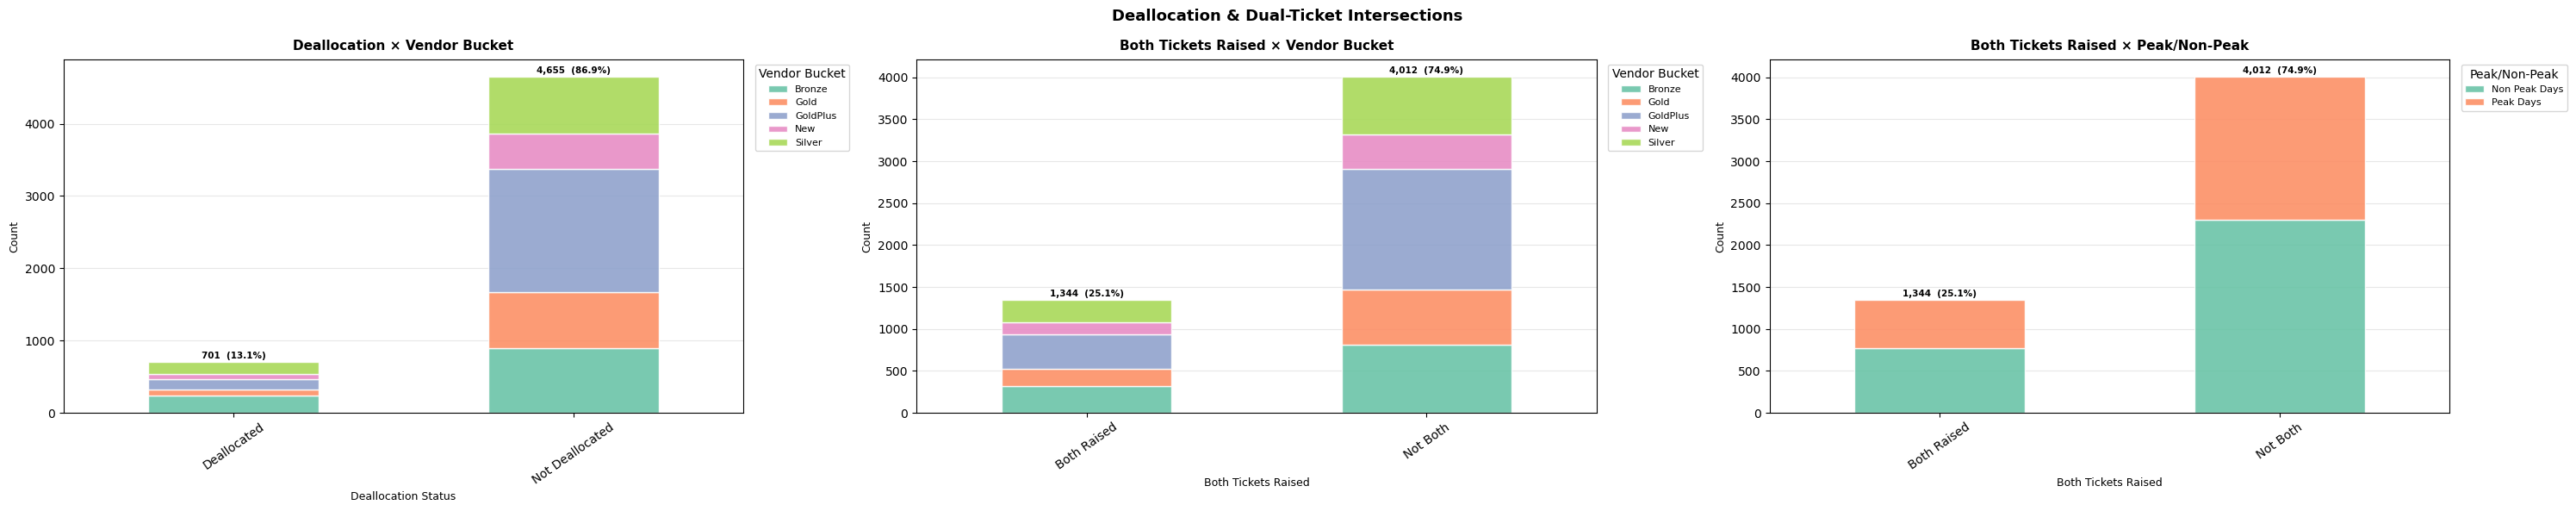

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(30, 6))
fig.suptitle("Deallocation & Dual-Ticket Intersections", fontsize=13, fontweight="bold")

df["_dealloc_str"] = df["DEALLOCATION_STATUS"].map({True: "Deallocated", False: "Not Deallocated"})

barplot_intersection(
    df, "_dealloc_str", "VENDOR_BUCKET_TYPE",
    row_label="Deallocation Status", col_label="Vendor Bucket",
    title="Deallocation × Vendor Bucket", ax=axes[0]
)
barplot_intersection(
    df, "cust_vendor_both_ticket", "VENDOR_BUCKET_TYPE",
    row_label="Both Tickets Raised", col_label="Vendor Bucket",
    title="Both Tickets Raised × Vendor Bucket", ax=axes[1]
)
barplot_intersection(
    df, "cust_vendor_both_ticket", "PEAK_OR_NON_PEAK_DAYS",
    row_label="Both Tickets Raised", col_label="Peak/Non-Peak",
    title="Both Tickets Raised × Peak/Non-Peak", ax=axes[2]
)

df.drop(columns=["_dealloc_str"], inplace=True)
plt.tight_layout()
plt.show()

### 5.11 Sprinklr Sessions × Ticket Load & FCR

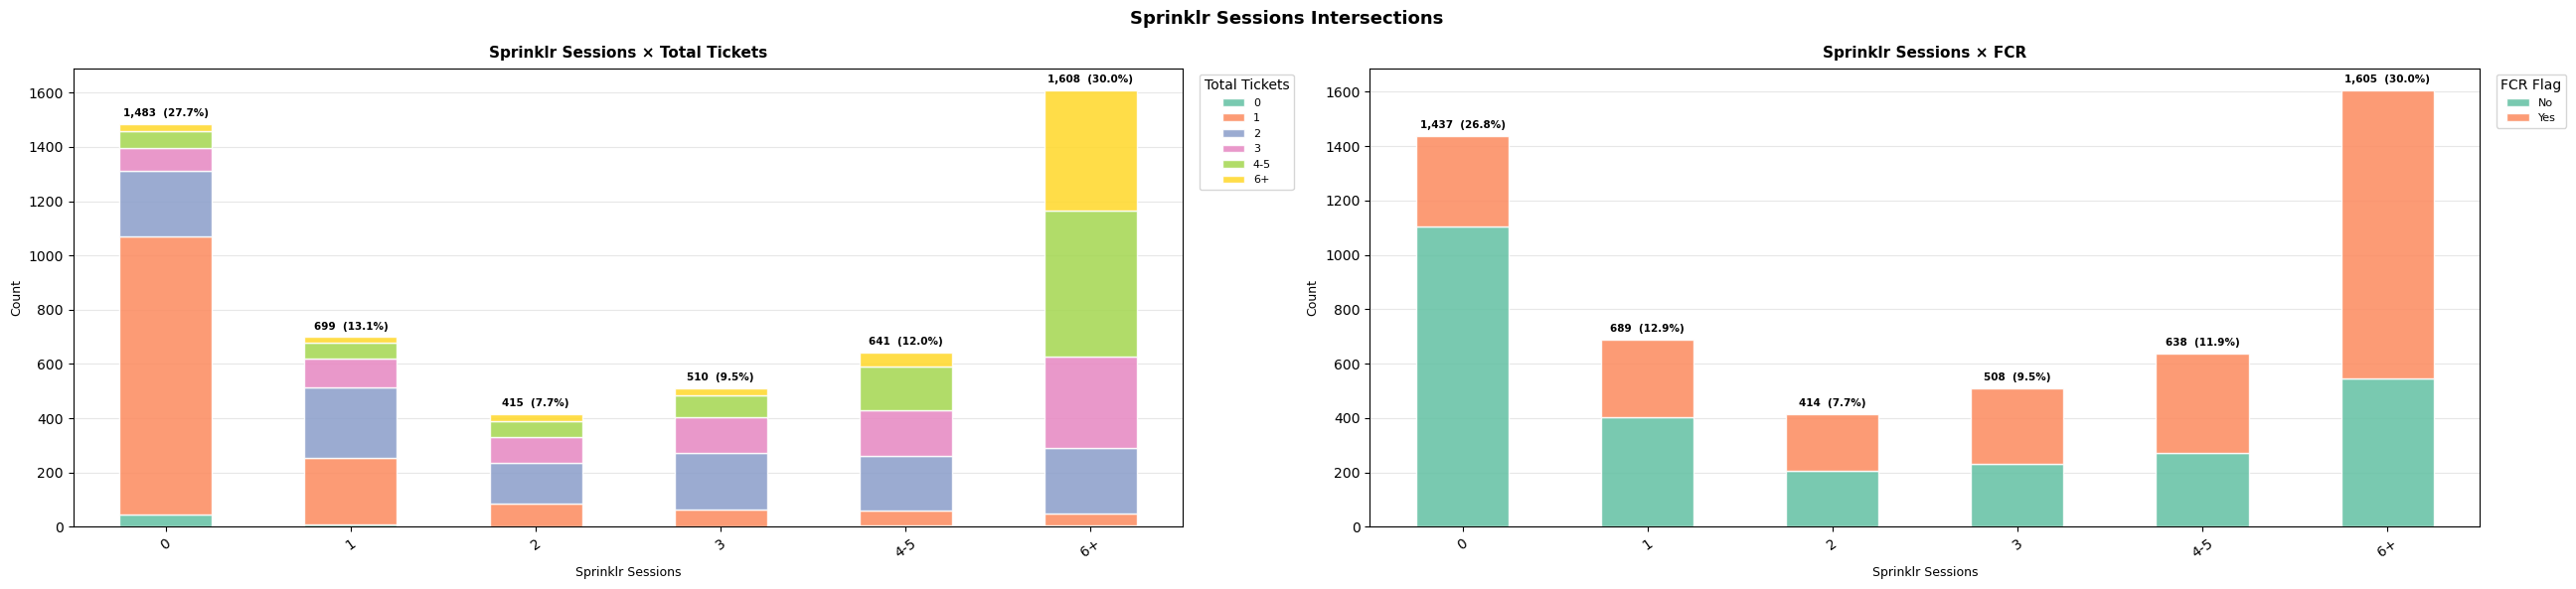

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(26, 6))
fig.suptitle("Sprinklr Sessions Intersections", fontsize=13, fontweight="bold")

barplot_intersection(df, "sprinklr_sessions_bin", "total_tickets_bin",
    row_label="Sprinklr Sessions", col_label="Total Tickets",
    title="Sprinklr Sessions × Total Tickets", ax=axes[0])
barplot_intersection(df, "sprinklr_sessions_bin", "FIRST_CONTACT_RESOLUTION_FLAG",
    row_label="Sprinklr Sessions", col_label="FCR Flag",
    title="Sprinklr Sessions × FCR", ax=axes[1])

plt.tight_layout()
plt.show()

### 5.12 Add-On Services × Vendor Bucket & Modification

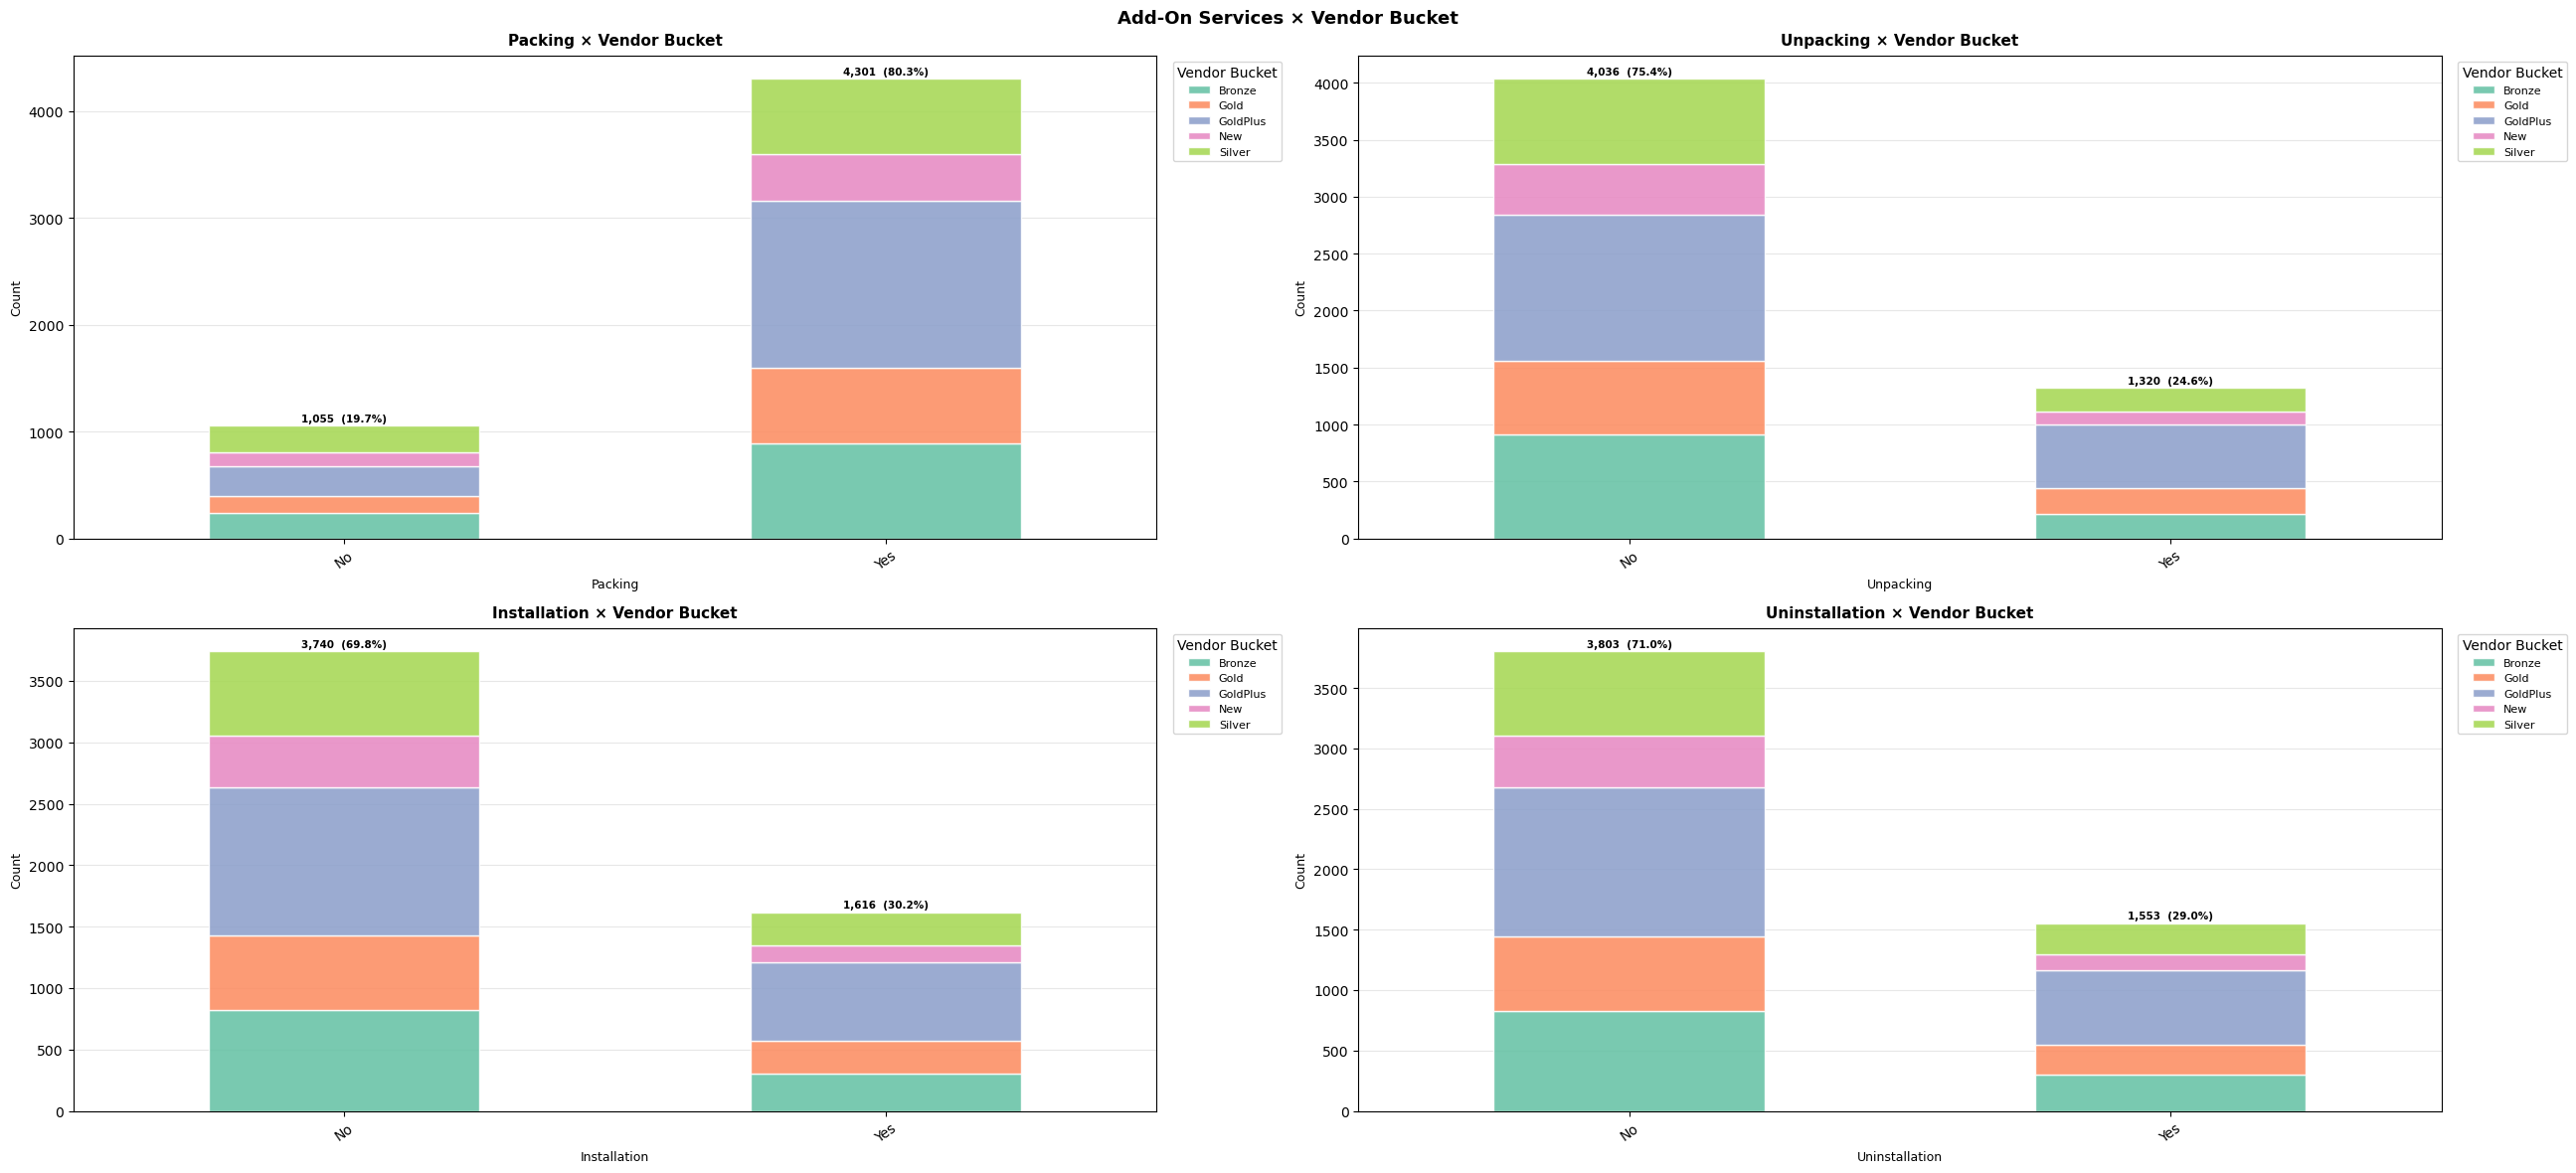

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(26, 12))
fig.suptitle("Add-On Services × Vendor Bucket", fontsize=13, fontweight="bold")

addon_info = [
    ("has_packing",        "Packing"),
    ("has_unpacking",      "Unpacking"),
    ("has_installation",   "Installation"),
    ("has_uninstallation", "Uninstallation"),
]

for ax, (col, lbl) in zip(axes.flatten(), addon_info):
    tmp_col = f"_tmp_{col}"
    df[tmp_col] = df[col].map({1: "Yes", 0: "No"})
    barplot_intersection(df, tmp_col, "VENDOR_BUCKET_TYPE",
        row_label=lbl, col_label="Vendor Bucket",
        title=f"{lbl} × Vendor Bucket", ax=ax)
    df.drop(columns=[tmp_col], inplace=True)

plt.tight_layout()
plt.show()

### 5.13 Summary Table — Top Segments by Detractor Volume

Tabular view of all major feature-level segments ranked by count.

In [ ]:
summary_features = {
    "Vendor Bucket":         "VENDOR_BUCKET_TYPE",
    "Total Tickets":         "total_tickets_bin",
    "Floor":                 "floor_bin",
    "Lift":                  "PICKUP_LIFT_STATUS",
    "Peak/Non-Peak":         "PEAK_OR_NON_PEAK_DAYS",
    "OTA Status":            "ota_binary",
    "FCR":                   "FIRST_CONTACT_RESOLUTION_FLAG",
    "Modification":          "IS_MODIFICATION_DONE",
    "Booking Lead":          "booking_lead_bin",
    "Sprinklr Sessions":     "sprinklr_sessions_bin",
    "Customer Tickets":      "customer_tickets_bin",
    "Vendor Tickets":        "vendor_tickets_bin",
    "CFT Change":            "cft_change_bin",
    "Dry Run Distance":      "dry_run_bin",
    "Deallocation":          "DEALLOCATION_STATUS",
    "Both Tickets":          "cust_vendor_both_ticket",
    "Weekend/Weekday":       "weekend_flag",
    "Resolution TAT":        "resolution_tat_bin",
    "Sup Behavioural Tkts":  "sup_bhv_bin",
}

rows = []
for feat_name, col in summary_features.items():
    vc = df[col].value_counts(dropna=False)
    for val, cnt in vc.items():
        rows.append({
            "Feature":    feat_name,
            "Segment":    str(val),
            "Count":      cnt,
            "% of Total": round(cnt / len(df) * 100, 1),
        })

summary_df = (
    pd.DataFrame(rows)
    .sort_values(["Feature", "Count"], ascending=[True, False])
    .reset_index(drop=True)
)

# Identify the top-count row index per feature for highlighting
top_idxs = set(summary_df.groupby("Feature")["Count"].idxmax().values)

def highlight_top(col):
    """Highlight the highest-count segment within each Feature group."""
    return [
        "background-color: #ffe0b2; font-weight: bold" if idx in top_idxs else ""
        for idx in col.index
    ]

styled = (
    summary_df.style
    .apply(highlight_top, subset=["Count", "% of Total"])
    .format({"Count": "{:,}", "% of Total": "{:.1f}%"})
)

display(styled)

,Feature,Segment,Count,% of Total
0,Booking Lead,1 day,"2,490",46.5%
1,Booking Lead,2-3 days,"1,495",27.9%
2,Booking Lead,4-7 days,849,15.9%
3,Booking Lead,7+ days,520,9.7%
4,Booking Lead,Same Day,2,0.0%
5,Both Tickets,Not Both,"4,012",74.9%
6,Both Tickets,Both Raised,"1,344",25.1%
7,CFT Change,No Change,"2,897",54.1%
8,CFT Change,+5+,"1,863",34.8%
9,CFT Change,Decreased,518,9.7%
